[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter8_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 8: Long memory and ARFIMA

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Short and long memory: exponential against hyperbolic decay of the ACF (Nile, inflation, volatility).
- Fractional differencing $(1-L)^d$, fractional integration, the ARFIMA$(p,d,q)$ model, fBm and fGn.
- Estimating $d$: R/S, DFA, GPH, local Whittle, exact ML (Durbin–Levinson) and Whittle; a Monte Carlo.
- Forecasting with ARFIMA against AR; long memory in volatility (FIGARCH, HAR); spurious long memory.
- The first code cell installs the `arch` package if it is missing (`pip install arch`).
- References: Granger and Joyeux (1980); Hosking (1981); Geweke and Porter-Hudak (1983); Robinson (1995); Sowell (1992); Baillie (1996); Ding, Granger and Engle (1993); Diebold and Inoue (2001).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_8'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
# The arch package (FIGARCH estimation) is not preinstalled in Google Colab: pip install arch
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- `frac_weights(d, n)`: weights of $(1-L)^d$; `arfima_acvf(d, phi, theta, sigma2, n)`: ARFIMA autocovariances.
- `gph(x, m)`, `local_whittle(x, m)`: semiparametric estimators with bandwidth $m = \lfloor T^{0.65}\rfloor$.
- `arfima_exact_ml(x, p, q)`: exact Gaussian ML; `arfima_whittle(x, p, q)`: Whittle approximation.
- `hurst_rs(x)`, `hurst_dfa(x)`: R/S and DFA exponents; `arfima_forecast(x, d, phi, theta, H)`: forecasts.
- `statsmodels` has no ARFIMA class: every estimator is written out here.

In [6]:
from scipy import special
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
SEED = 2026
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
INFL_START = '2005-01-01'
BW = 0.65
NMIN = 10
WINDOW, STEP = 1000, 21
MC_REPS = 300
LO_CRIT = (0.809, 1.862)
NAME = {'nile': 'Nile flow', 'infl': 'RO inflation (monthly, SA)', 'infl12': 'RO inflation (12-month)', 'usinfl': 'US inflation (monthly, annualised)', 'unrate': 'US unemployment', 'sp500': 'S&P 500', 'bet': 'BET', 'eurron': 'EUR/RON'}
NILE_BREAK = 1898
SHIFTS = [0.0, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
SWITCH = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.05, 0.2]
RS_EXAMPLE = [0.5, -0.3, 0.8, -0.2, 0.6, -0.1, 0.4, -0.7]
COLORS = {'nile': st.MainBlue, 'infl': st.IDAred, 'infl12': st.Orange, 'usinfl': st.Forest, 'unrate': st.Purple, 'sp500': st.COL['sp500'], 'bet': st.COL['bet'], 'eurron': st.COL['eurron'], 'abs': st.Purple, 'sq': st.Orange}
HERE = "."


def nile():
    """Annual flow of the Nile at Aswan, 1871-1970, 10^8 cubic metres (Cobb 1978; statsmodels data set)."""
    s = load_statsmodels('nile')
    s.index = s.index.year
    return s


def ro_hicp():
    """Romanian HICP, monthly, 2015 = 100 (Eurostat prc_hicp_minr)."""
    return read_eurostat(*HICP)


def ro_inflation12(start=INFL_START):
    """Romanian 12-month inflation, 100 ln(P_t / P_{t-12}), in % (overlapping: each value sums 12 monthly changes)."""
    return (100 * np.log(ro_hicp()).diff(12)).dropna().loc[start:].rename('infl12')


def seasonal_adjust(x):
    """Remove the monthly means (a simple seasonal adjustment, Chapter 4); returns the adjusted series and the means."""
    means = x.groupby(x.index.month).mean()
    return x - means.reindex(x.index.month).values, means


def ro_inflation(start=INFL_START):
    """Romanian monthly inflation, 100 ln(P_t / P_{t-1}) in %, seasonally adjusted with the monthly means, plus the
    sample mean (so that the level is kept)."""
    x = (100 * np.log(ro_hicp()).diff()).dropna().loc[start:]
    sa, _ = seasonal_adjust(x)
    return (sa + x.mean()).rename('infl')


def us_inflation(start=None, end=None):
    """US monthly CPI inflation, annualised: 1200 ln(CPI_t / CPI_{t-1}), in % (FRED CPIAUCSL, seasonally adjusted)."""
    cpi = read_fred('CPIAUCSL').dropna()
    return (1200 * np.log(cpi).diff()).dropna().loc[start:end].rename('usinfl')


def us_unemployment(start=None, end=None):
    """US civilian unemployment rate, monthly, seasonally adjusted, in % (FRED UNRATE)."""
    return read_fred('UNRATE').dropna().loc[start:end].rename('unrate')


def returns(name, start='2000-01-01'):
    """Daily log returns in % (EODHD; EUR/RON: BNR reference rate)."""
    return log_returns(name, start if name != 'eurron' else None)


def monthly_rv(name):
    """Monthly realised volatility from daily returns: RV_m = sqrt(sum of r_t^2 in month m), in %; log RV."""
    r = returns(name)
    rv = np.sqrt((r ** 2).resample('MS').sum())
    return np.log(rv[rv > 0]).rename(name)


def parkinson_vol(name='sp500'):
    """Daily range-based volatility (Parkinson 1980), in %: 100 sqrt((ln H_t - ln L_t)^2 / (4 ln 2)); a realised-volatility
    proxy from the daily high and low (only for series with OHLC data)."""
    o = load_ohlc(name, '2000-01-01')
    v = 100 * np.sqrt(np.log(o['high'] / o['low']) ** 2 / (4 * np.log(2)))
    return v[v > 0].rename(name)


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def frac_weights(d, n):
    """Weights pi_0..pi_{n-1} of (1 - L)^d = sum pi_k L^k: pi_0 = 1, pi_k = pi_{k-1} (k - 1 - d) / k."""
    w = np.ones(n)
    for k in range(1, n):
        w[k] = w[k - 1] * (k - 1 - d) / k
    return w


def frac_diff(x, d, thresh=None):
    """(1 - L)^d x_t with all available past values (expanding window), or, with thresh, the fixed-width window
    whose weights are larger than thresh in absolute value (FFD)."""
    x = np.asarray(x, float)
    w = frac_weights(d, len(x))
    if thresh is not None:
        w = w[:max(int(np.argmax(np.abs(w) < thresh)), 2)] if np.any(np.abs(w) < thresh) else w
        K = len(w)
        return np.array([w @ x[t - K + 1:t + 1][::-1] for t in range(K - 1, len(x))])
    return np.array([w[:t + 1] @ x[t::-1] for t in range(len(x))])


def arfima_acvf0(d, n):
    """Autocovariances of ARFIMA(0,d,0) with unit innovation variance, lags 0..n-1:
    gamma(0) = Gamma(1 - 2d) / Gamma(1 - d)^2, gamma(k) = gamma(k-1) (k - 1 + d) / (k - d)."""
    g = np.empty(n)
    g[0] = np.exp(special.gammaln(1 - 2 * d) - 2 * special.gammaln(1 - d))
    for k in range(1, n):
        g[k] = g[k - 1] * (k - 1 + d) / (k - d)
    return g


def arma_psi(phi, theta, n):
    """psi weights of theta(L) / phi(L): x_t = sum psi_j u_{t-j} (phi(L) = 1 - phi_1 L - ..., theta(L) = 1 + theta_1 L + ...)."""
    psi = np.zeros(n)
    psi[0] = 1.0
    for j in range(1, n):
        psi[j] = (theta[j - 1] if j <= len(theta) else 0.0) + sum(phi[i] * psi[j - 1 - i] for i in range(min(len(phi), j)))
    return psi


def arfima_acvf(d, phi=(), theta=(), sigma2=1.0, n=100, K=None):
    """Autocovariances of ARFIMA(p,d,q), lags 0..n-1: the ARFIMA(0,d,0) autocovariances filtered by the ARMA psi
    weights (truncated at K terms), gamma_X(h) = sum_m c(m) [gamma_U(h + m) + gamma_U(|h - m|)], c the ARMA
    autocovariance of the psi weights."""
    phi, theta = list(phi), list(theta)
    if not phi and not theta:
        return sigma2 * arfima_acvf0(d, n)
    if K is None:
        r = np.abs(np.roots([1] + [-a for a in phi])).max() if phi else 0.0
        K = 1 + len(theta) if r == 0 else int(min(3000, max(50, np.ceil(np.log(1e-10) / np.log(r)))))
    K = max(K, len(theta) + 1)
    psi = arma_psi(phi, theta, K)
    c = np.array([psi[:K - m] @ psi[m:] for m in range(K)])
    gU = arfima_acvf0(d, n + K)
    h = np.arange(n)
    g = c[0] * gU[h]
    for m in range(1, K):
        g = g + c[m] * (gU[h + m] + gU[np.abs(h - m)])
    return sigma2 * g


def arfima_acf(d, n):
    """Autocorrelations of ARFIMA(0,d,0), lags 0..n-1: rho_k = rho_{k-1} (k - 1 + d) / (k - d)."""
    g = arfima_acvf0(d, n)
    return g / g[0]


def ma_inf_weights(d, phi=(), theta=(), n=200):
    """Impulse responses psi_k of ARFIMA(p,d,q): coefficients of theta(L) / (phi(L) (1 - L)^d)."""
    a = frac_weights(-d, n)                       # (1 - L)^(-d)
    b = arma_psi(list(phi), list(theta), n)
    return np.convolve(a, b)[:n]


def ar_inf_weights(d, phi=(), theta=(), n=200):
    """AR(infinity) weights: pi(L) = phi(L) (1 - L)^d / theta(L) = sum pi_k L^k, pi_0 = 1."""
    a = frac_weights(d, n)
    ph = np.r_[1.0, -np.asarray(phi, float)] if len(phi) else np.array([1.0])
    num = np.convolve(a, ph)[:n]
    inv_theta = arma_psi([-t for t in theta], [], n) if len(theta) else np.r_[1.0, np.zeros(n - 1)]   # 1 / theta(L)
    return np.convolve(num, inv_theta)[:n]


def fgn_acvf(n, H):
    """Autocovariances of standard fractional Gaussian noise: 0.5 (|k+1|^2H - 2|k|^2H + |k-1|^2H), k = 0..n-1."""
    k = np.arange(n, dtype=float)
    return 0.5 * (np.abs(k + 1) ** (2 * H) - 2 * k ** (2 * H) + np.abs(k - 1) ** (2 * H))


def circulant_gaussian(acvf, rng, size=1):
    """Exact simulation of a stationary Gaussian series with autocovariances acvf[0..n-1] by circulant embedding
    (Davies and Harte); returns an array (size, n)."""
    n = len(acvf)
    c = np.concatenate([acvf, acvf[-2:0:-1]])
    M = len(c)
    lam = np.clip(np.fft.fft(c).real, 0, None)
    Z = rng.standard_normal((size, M)) + 1j * rng.standard_normal((size, M))
    W = np.fft.fft(np.sqrt(lam / M) * Z, axis=1)
    return W.real[:, :n]


def sim_arfima(n, d, rng, size=1, phi=()):
    """ARFIMA(0,d,0) (exact, circulant embedding) or ARFIMA(1,d,0) (the AR(1) filter applied to it, with burn-in)."""
    if not len(phi):
        return circulant_gaussian(arfima_acvf0(d, n), rng, size)
    u = circulant_gaussian(arfima_acvf0(d, n + 300), rng, size)
    x = np.zeros_like(u)
    for t in range(u.shape[1]):
        x[:, t] = u[:, t] + (phi[0] * x[:, t - 1] if t else 0)
    return x[:, 300:]


def sim_fgn(n, H, rng, size=1):
    return circulant_gaussian(fgn_acvf(n, H), rng, size)


def acf(x, nlags):
    """Sample autocorrelations at lags 1..nlags."""
    x = np.asarray(x, float) - np.mean(x)
    g0 = x @ x
    return np.array([x[k:] @ x[:-k] / g0 for k in range(1, nlags + 1)])


def block_sizes(N, nmin=NMIN, nmax=None, num=20):
    """Block sizes for R/S and DFA: about `num` values spaced evenly on a log scale between nmin and N/4."""
    nmax = nmax or N // 4
    return np.unique(np.floor(np.logspace(np.log10(nmin), np.log10(nmax), num)).astype(int))


def rs_curve(x, sizes=None):
    """Average R/S over the non-overlapping blocks of each size n (Hurst 1951; Mandelbrot and Wallis 1969)."""
    x = np.asarray(x, float)
    sizes = block_sizes(len(x)) if sizes is None else np.asarray(sizes)
    out = []
    for n in sizes:
        m = len(x) // n
        X = x[:m * n].reshape(m, n)
        Y = np.cumsum(X - X.mean(axis=1, keepdims=True), axis=1)
        R = Y.max(axis=1) - Y.min(axis=1)
        S = X.std(axis=1)
        ok = S > 0
        out.append(np.mean(R[ok] / S[ok]))
    return sizes, np.array(out)


def hurst_rs(x, sizes=None):
    """Hurst exponent: slope of log(R/S)_n on log n."""
    n, rs = rs_curve(x, sizes)
    return float(np.polyfit(np.log10(n), np.log10(rs), 1)[0])


def rs_steps(x):
    """All steps of the R/S statistic of one short block: mean, deviations, cumulative deviations, R, S, R/S."""
    x = np.asarray(x, float)
    dev = x - x.mean()
    Y = np.cumsum(dev)
    return {'mean': float(x.mean()), 'dev': dev.tolist(), 'Y': Y.tolist(), 'max': float(Y.max()), 'min': float(Y.min()),
            'R': float(Y.max() - Y.min()), 'S': float(x.std()), 'RS': float((Y.max() - Y.min()) / x.std())}


def dfa_curve(x, sizes=None):
    """DFA-1 (Peng et al. 1994): profile Y = cumsum(x - mean); in each block of size n a straight line is fitted
    to Y; F(n) is the root mean square of the deviations from the lines."""
    x = np.asarray(x, float)
    sizes = block_sizes(len(x)) if sizes is None else np.asarray(sizes)
    Y = np.cumsum(x - x.mean())
    F = []
    for n in sizes:
        m = len(Y) // n
        B = Y[:m * n].reshape(m, n)
        t = np.arange(n) - (n - 1) / 2
        b = (B - B.mean(axis=1, keepdims=True)) @ t / (t @ t)
        resid = B - B.mean(axis=1, keepdims=True) - np.outer(b, t)
        F.append(np.sqrt(np.mean(resid ** 2)))
    return sizes, np.array(F)


def hurst_dfa(x, sizes=None):
    """DFA exponent: slope of log F(n) on log n (H for a stationary series)."""
    n, F = dfa_curve(x, sizes)
    return float(np.polyfit(np.log10(n), np.log10(F), 1)[0])


def periodogram(x):
    """I(lambda_j) = |sum_t x_t exp(-i lambda_j t)|^2 / (2 pi T) at the Fourier frequencies lambda_j = 2 pi j / T."""
    x = np.asarray(x, float)
    T = len(x)
    I = np.abs(np.fft.fft(x - x.mean())) ** 2 / (2 * np.pi * T)
    j = np.arange(1, T // 2 + 1)
    return 2 * np.pi * j / T, I[1:T // 2 + 1]


def bandwidth(T, power=BW):
    return int(np.floor(T ** power))


def gph(x, m=None):
    """GPH estimator (Geweke and Porter-Hudak 1983): OLS slope of log I(lambda_j) on -log(4 sin^2(lambda_j / 2)),
    j = 1..m; asymptotic standard error pi / sqrt(24 m)."""
    lam, I = periodogram(x)
    m = m or bandwidth(len(x))
    X = -np.log(4 * np.sin(lam[:m] / 2) ** 2)
    d = float(np.polyfit(X, np.log(I[:m]), 1)[0])
    return {'d': d, 'se': float(np.pi / np.sqrt(24 * m)), 'm': int(m)}


def local_whittle(x, m=None):
    """Local Whittle estimator (Robinson 1995): d minimises R(d) = log G(d) - 2d mean(log lambda_j), with
    G(d) = mean(lambda_j^(2d) I(lambda_j)), j = 1..m; standard error 1 / (2 sqrt(m))."""
    lam, I = periodogram(x)
    m = m or bandwidth(len(x))
    lam, I = lam[:m], I[:m]
    R = lambda d: np.log(np.mean(lam ** (2 * d) * I)) - 2 * d * np.mean(np.log(lam))
    d = float(optimize.minimize_scalar(R, bounds=(-0.49, 1.49), method='bounded').x)
    return {'d': d, 'se': float(0.5 / np.sqrt(m)), 'm': int(m)}


def dl_quad_logdet(x, g):
    """Durbin-Levinson: the quadratic form x' G^-1 x and log det G of the Toeplitz matrix G of g[0..n-1]."""
    n = len(x)
    phi = np.zeros(0)
    v = g[0]
    Q, L = x[0] ** 2 / v, np.log(v)
    for t in range(1, n):
        k = (g[t] - phi @ g[t - 1:0:-1]) / v
        phi = np.r_[phi - k * phi[::-1], k]
        v = v * (1 - k ** 2)
        e = x[t] - phi @ x[t - 1::-1]
        Q += e ** 2 / v
        L += np.log(v)
    return Q, L


def _unpack(par, p, q):
    return par[0], list(par[1:1 + p]), list(par[1 + p:1 + p + q])


def _ok(phi, theta):
    r1 = np.abs(np.roots([1] + [-a for a in phi])) if phi else np.array([0.0])
    r2 = np.abs(np.roots([1] + list(theta))) if theta else np.array([0.0])
    return r1.max() < 0.97 and r2.max() < 0.97


def arfima_exact_ml(x, p=0, q=0, se=True, fix_d=None):
    """Exact Gaussian maximum likelihood of ARFIMA(p,d,q) (Sowell 1992) for -0.49 < d < 0.49: the Toeplitz
    likelihood from the ARFIMA autocovariances, computed with the Durbin-Levinson algorithm; the mean is the sample
    mean and sigma^2 is concentrated out (sigma2 = x' G^-1 x / n)."""
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)

    def negll(par):
        par = np.r_[fix_d, par] if fix_d is not None else par
        d, phi, theta = _unpack(par, p, q)
        if not -0.49 < d < 0.49 or not _ok(phi, theta):
            return 1e10
        Q, L = dl_quad_logdet(x, arfima_acvf(d, phi, theta, 1.0, n))
        return 0.5 * (n * np.log(2 * np.pi * Q / n) + L + n)

    best = None
    for d0 in ((0.1, 0.35) if fix_d is None else (None,)):
        x0 = ([d0] if fix_d is None else []) + [0.3] * p + [0.1] * q
        if not x0:                                   # nothing to estimate: white noise
            best = optimize.OptimizeResult(x=np.zeros(0), fun=negll(np.zeros(0)))
            break
        r = optimize.minimize(negll, x0, method='Nelder-Mead' if len(x0) > 1 else 'Nelder-Mead',
                              options={'xatol': 1e-5, 'fatol': 1e-8, 'maxiter': 4000})
        if best is None or r.fun < best.fun:
            best = r
    full = np.r_[fix_d, best.x] if fix_d is not None else best.x
    d, phi, theta = _unpack(full, p, q)
    Q, L = dl_quad_logdet(x, arfima_acvf(d, phi, theta, 1.0, n))
    ll = float(-best.fun)
    k = 1 + (fix_d is None) + p + q
    s = (_se_numeric(negll, best.x) if se and len(best.x) else []) or [float('nan')] * len(best.x)
    if fix_d is not None:
        s = [float('nan')] + s
    return {'d': float(d), 'phi': [float(v) for v in phi], 'theta': [float(v) for v in theta], 'sigma2': float(Q / n),
            'loglik': ll, 'aic': -2 * ll + 2 * k, 'bic': -2 * ll + np.log(n) * k, 'se_d': s[0], 'se': s, 'n': n,
            'p': p, 'q': q}


def _se_numeric(f, x, h=1e-3):
    """Standard errors from the numerical Hessian of a negative log-likelihood."""
    x = np.asarray(x, float)
    k = len(x)
    Hm = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            ei, ej = np.eye(k)[i] * h, np.eye(k)[j] * h
            Hm[i, j] = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * h * h)
    try:
        return [float(s) for s in np.sqrt(np.clip(np.diag(np.linalg.inv(Hm)), 0, None))]
    except np.linalg.LinAlgError:
        return [float('nan')] * k


def arfima_spec(lam, d, phi=(), theta=()):
    """Spectral shape of ARFIMA(p,d,q) (sigma^2 / 2 pi omitted): |theta(e^-il)|^2 / |phi(e^-il)|^2 |1 - e^-il|^(-2d)."""
    z = np.exp(-1j * lam)
    num = np.abs(1 + sum(t * z ** (k + 1) for k, t in enumerate(theta))) ** 2
    den = np.abs(1 - sum(a * z ** (k + 1) for k, a in enumerate(phi))) ** 2
    return num / den * np.abs(1 - z) ** (-2 * d)


def arfima_whittle(x, p=0, q=0):
    """Whittle (approximate) maximum likelihood of ARFIMA(p,d,q) (Fox and Taqqu 1986): minimise
    log mean(I_j / f_j) + mean(log f_j) over all Fourier frequencies, sigma^2 concentrated out."""
    lam, I = periodogram(x)
    lam, I = lam[:-1], I[:-1]

    def obj(par):
        d, phi, theta = _unpack(par, p, q)
        if not -0.49 < d < 0.99 or not _ok(phi, theta):
            return 1e10
        f = arfima_spec(lam, d, phi, theta)
        return np.log(np.mean(I / f)) + np.mean(np.log(f))

    best = None
    for d0 in (0.1, 0.3):
        r = optimize.minimize(obj, [d0] + [0.3] * p + [0.1] * q, method='Nelder-Mead',
                              options={'xatol': 1e-6, 'fatol': 1e-9, 'maxiter': 4000})
        if best is None or r.fun < best.fun:
            best = r
    d, phi, theta = _unpack(best.x, p, q)
    f = arfima_spec(lam, d, phi, theta)
    s2 = float(2 * np.pi * np.mean(I / f))
    n = len(x)
    ll = -0.5 * n * (np.log(2 * np.pi) + best.fun + np.log(s2 / (2 * np.pi)) + 1)   # Whittle approximation
    k = 2 + p + q
    return {'d': float(d), 'phi': phi, 'theta': theta, 'sigma2': s2, 'loglik': float(ll), 'aic': float(-2 * ll + 2 * k),
            'bic': float(-2 * ll + np.log(n) * k), 'n': n, 'p': p, 'q': q}


def lo_test(x, q=None):
    """Lo's (1991) modified R/S: V(q) = R / (sqrt(N) sigma(q)), sigma^2(q) the Newey-West variance with Bartlett
    weights; q by the Andrews (1991) rule. Short memory is rejected at 5% if V is outside [0.809, 1.862]."""
    x = np.asarray(x, float)
    N = len(x)
    xc = x - x.mean()
    Y = np.cumsum(xc)
    R = Y.max() - Y.min()
    g0 = xc @ xc / N
    rho = (xc[1:] @ xc[:-1] / N) / g0
    if q is None:
        q = int(np.floor((1.5 * N) ** (1 / 3) * (2 * abs(rho) / (1 - rho ** 2)) ** (2 / 3)))
    s2 = g0 + 2 * sum((1 - j / (q + 1)) * (xc[j:] @ xc[:-j] / N) for j in range(1, q + 1))
    V = R / np.sqrt(N * s2)
    return {'V': float(V), 'V0': float(R / np.sqrt(N * g0)), 'q': int(q), 'reject': bool(not LO_CRIT[0] <= V <= LO_CRIT[1])}


def all_estimates(x):
    """R/S and DFA exponents, GPH and local Whittle d (bandwidth [T^0.65]), Lo's test of one series."""
    x = np.asarray(x, float)
    g, lw, lo = gph(x), local_whittle(x), lo_test(x)
    return {'n': int(len(x)), 'rs': hurst_rs(x), 'dfa': hurst_dfa(x), 'gph': g['d'], 'gph_se': g['se'], 'lw': lw['d'],
            'lw_se': lw['se'], 'm': g['m'], 'lo_V': lo['V'], 'lo_q': lo['q'], 'lo_reject': lo['reject']}


def arfima_forecast(x, d, phi=(), theta=(), H=24):
    """h-step forecasts, h = 1..H, of a demeaned ARFIMA(p,d,q) from its AR(infinity) form
    x_t = -sum_{k>=1} pi_k x_{t-k} + e_t, using all observed values (forecasts replace the future ones)."""
    x = np.asarray(x, float)
    mu = x.mean()
    T = len(x)
    z = np.r_[x - mu, np.zeros(H)]
    pi = ar_inf_weights(d, phi, theta, T + H)
    for j in range(H):
        t = T + j
        z[t] = -pi[1:t + 1] @ z[t - 1::-1]
    return z[T:] + mu


def ar_forecast(x, H=24, pmax=12):
    """Forecasts of an AR(p) with constant, p chosen by AIC on a common sample (p <= pmax)."""
    x = np.asarray(x, float)
    p = min(range(1, pmax + 1), key=lambda k: AutoReg(x[pmax - k:], lags=k, trend='c').fit().aic)
    return np.asarray(AutoReg(x, lags=p, trend='c').fit().forecast(H)), p


def oos_inflation(series, start, H=24, refit=12, seasonal=False):
    """Pseudo out-of-sample comparison (expanding window, origins from `start`): ARFIMA(1,d,0) (Whittle, re-estimated
    every `refit` months), AR(p) by AIC, the random walk and the sample mean; RMSE by horizon. With seasonal=True the
    raw monthly series is seasonally adjusted inside each window (window monthly means) and the means are added back."""
    idx = series.index
    origins = [t for t in range(len(series)) if idx[t] >= pd.Timestamp(start) and t + H < len(series)]
    E = {m: [] for m in ('ARFIMA', 'AR', 'RW', 'Mean')}
    est, ps = None, []
    for i, t in enumerate(origins):
        w = series.iloc[:t + 1]
        if seasonal:
            sa, means = seasonal_adjust(w)
            y = sa.values + w.mean()
            fut = pd.date_range(idx[t], periods=H + 1, freq='MS')[1:]
            add = means.reindex(fut.month).values - w.mean()
        else:
            y, add = w.values, np.zeros(H)
        if i % refit == 0:
            est = arfima_whittle(y, 1, 0)
        fa, p = ar_forecast(y, H)
        ps.append(p)
        f = {'ARFIMA': arfima_forecast(y, est['d'], est['phi'], [], H), 'AR': fa,
             'RW': np.repeat(y[-1], H), 'Mean': np.repeat(y.mean(), H)}
        act = series.values[t + 1:t + H + 1]
        for m in E:
            E[m].append(act - (f[m] + add))
    rmse = {m: np.sqrt(np.mean(np.array(e) ** 2, axis=0)) for m, e in E.items()}
    return {'n': len(origins), 'first': idx[origins[0]].date().isoformat(), 'last': idx[origins[-1]].date().isoformat(),
            'rmse': {m: v.tolist() for m, v in rmse.items()}, 'last_est': {'d': est['d'], 'phi': est['phi'][0]},
            'p_median': float(np.median(ps)), 'p_min': int(min(ps)), 'p_max': int(max(ps))}


def rolling_d(x, window, step, est=local_whittle):
    """d estimated on rolling windows; dated at the last observation of the window."""
    x = pd.Series(x)
    idx, val = [], []
    for e in range(window, len(x) + 1, step):
        idx.append(x.index[e - 1])
        val.append(est(x.values[e - window:e])['d'])
    return pd.Series(val, index=idx)


def rolling_hurst(x, window=WINDOW, step=STEP):
    """DFA exponent on rolling windows; dated at the last day of the window."""
    x = pd.Series(x)
    sizes = block_sizes(window)
    idx, val = [], []
    for e in range(window, len(x) + 1, step):
        idx.append(x.index[e - 1])
        val.append(hurst_dfa(x.values[e - window:e], sizes))
    return pd.Series(val, index=idx)


def mc_band(n, est, reps=MC_REPS, seed=SEED):
    """2.5% and 97.5% quantiles of an estimator on i.i.d. N(0,1) series of length n."""
    rng = np.random.default_rng(seed + n)
    v = np.array([est(rng.standard_normal(n)) for _ in range(reps)])
    return {'q025': float(np.quantile(v, 0.025)), 'q975': float(np.quantile(v, 0.975)), 'mean': float(v.mean())}


def figarch_weights(d, phi, beta, n=1000):
    """ARCH(infinity) weights of FIGARCH(1,d,1): lambda(L) = 1 - (1 - beta L)^(-1) (1 - phi L) (1 - L)^d."""
    a = np.convolve(frac_weights(d, n), [1, -phi])[:n]
    a = np.convolve(a, beta ** np.arange(n))[:n]
    return -a[1:]

## 1. Memory in data

- Four persistent series and their ACF against an AR(1).

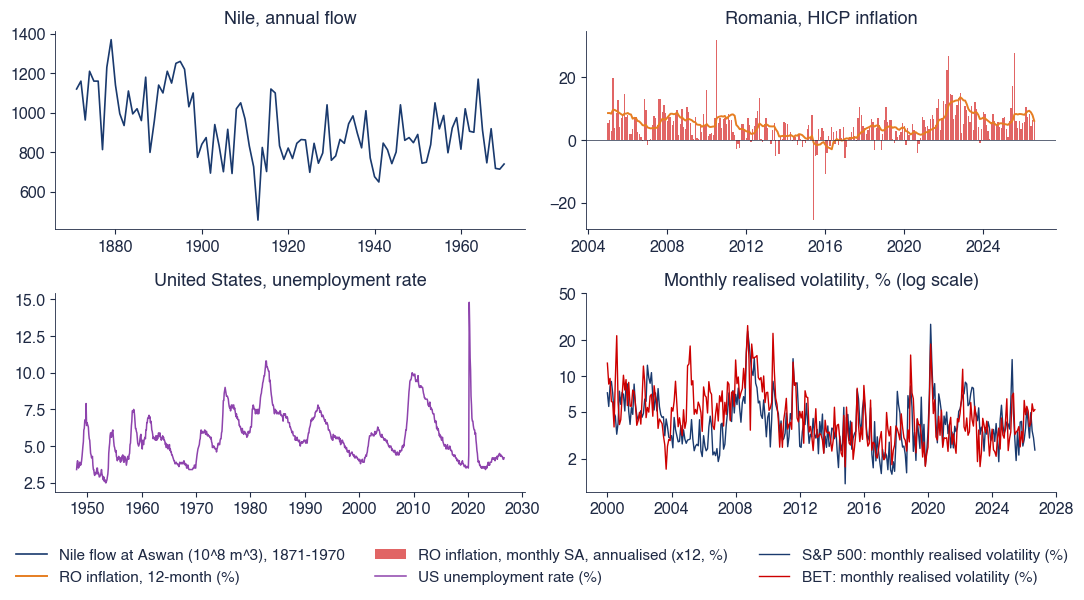

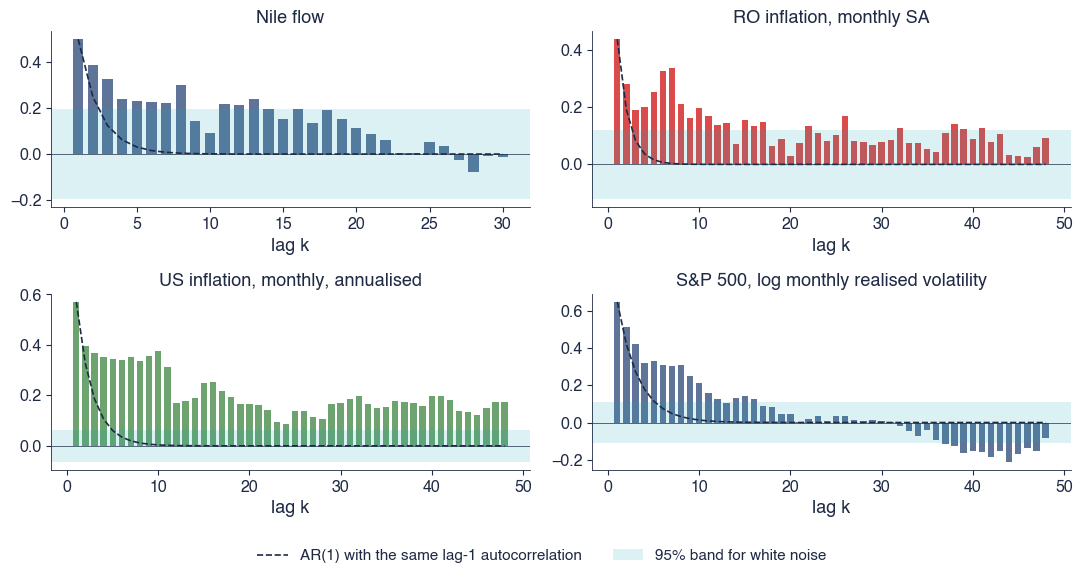

{'n': 260, 'r1': 0.4365550504829098, 'r10': 0.19572094113176722, 'rL': 0.09106142624726567, 'L': 48, 'ar10': 0.00025141441184502606, 'arL': 5.270754787957517e-18, 'npos': 22, 'band': 0.12155403989742429, 'sum': 6.183824088748942}


In [7]:
def fig_memory_data(save_it=True):
    """Four persistent series: the Nile, Romanian inflation (12-month and monthly SA), US unemployment, monthly realised
    volatility of the S&P 500 and the BET."""
    fig, ax = plt.subplots(2, 2, figsize=(11, 5.6))
    y = nile()
    ax[0, 0].plot(y.index, y.values, color=COLORS['nile'], lw=1.2, label='Nile flow at Aswan (10^8 m^3), 1871-1970')
    ax[0, 0].set_title('Nile, annual flow')
    i12, im = ro_inflation12(), ro_inflation()
    ax[0, 1].plot(i12.index, i12.values, color=COLORS['infl12'], lw=1.4, label='RO inflation, 12-month (%)')
    ax[0, 1].bar(im.index, 12 * im.values, width=25, color=COLORS['infl'], alpha=0.6,
                 label='RO inflation, monthly SA, annualised (x12, %)')
    ax[0, 1].axhline(0, color=st.DarkText, lw=0.5)
    ax[0, 1].set_title('Romania, HICP inflation')
    u = us_unemployment()
    ax[1, 0].plot(u.index, u.values, color=COLORS['unrate'], lw=1.1, label='US unemployment rate (%)')
    ax[1, 0].set_title('United States, unemployment rate')
    rv = {k: monthly_rv(k) for k in ('sp500', 'bet')}
    for k, v in rv.items():
        ax[1, 1].plot(v.index, np.exp(v.values), color=COLORS[k], lw=1.0, label=f'{NAME[k]}: monthly realised volatility (%)')
    ax[1, 1].set_yscale('log')
    ax[1, 1].set_yticks([2, 5, 10, 20, 50])
    ax[1, 1].set_yticklabels(['2', '5', '10', '20', '50'])
    ax[1, 1].minorticks_off()
    ax[1, 1].set_title('Monthly realised volatility, % (log scale)')
    st.fig_legend_bottom(fig, ncol=3, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_memory_data', save_it)
    return {'nile_n': int(len(y)), 'nile_mean': float(y.mean()), 'i12_max': float(i12.max()),
            'i12_max_d': i12.idxmax().date().isoformat(), 'i12_last': float(i12.iloc[-1]),
            'i12_last_d': i12.index[-1].date().isoformat(), 'im_n': int(len(im)), 'im_first': im.index[0].date().isoformat(),
            'im_last': im.index[-1].date().isoformat(), 'u_n': int(len(u)),
            'u_first': u.index[0].date().isoformat(), 'u_last': float(u.iloc[-1]), 'u_last_d': u.index[-1].date().isoformat(),
            'u_max': float(u.max()), 'u_max_d': u.idxmax().date().isoformat(),
            'rv_max': {k: float(np.exp(v.max())) for k, v in rv.items()},
            'rv_max_d': {k: v.idxmax().date().isoformat() for k, v in rv.items()}}


def fig_memory_acf(save_it=True):
    """Sample ACF of four series against the exponential decay rho_1^k of an AR(1) with the same lag-1
    autocorrelation."""
    S = [('nile', nile().values, 30), ('infl', ro_inflation().values, 48),
         ('usinfl', us_inflation().values, 48), ('sp500', monthly_rv('sp500').values, 48)]
    titles = {'nile': 'Nile flow', 'infl': 'RO inflation, monthly SA', 'usinfl': 'US inflation, monthly, annualised',
              'sp500': 'S&P 500, log monthly realised volatility'}
    fig, ax = plt.subplots(2, 2, figsize=(11, 5.6))
    out = {}
    for a, (k, x, L) in zip(ax.flat, S):
        r = acf(x, L)
        lags = np.arange(1, L + 1)
        band = 1.96 / np.sqrt(len(x))
        a.bar(lags, r, color=COLORS.get(k, st.MainBlue), alpha=0.7, width=0.7, label='_')
        a.plot(lags, r[0] ** lags, color=st.DarkText, ls='--', lw=1.2,
               label='AR(1) with the same lag-1 autocorrelation' if k == 'nile' else '_')
        a.axhspan(-band, band, color=st.Teal, alpha=0.15, lw=0, label='95% band for white noise' if k == 'nile' else '_')
        a.axhline(0, color=st.DarkText, lw=0.5)
        a.set_title(titles[k])
        a.set_xlabel('lag k')
        out[k] = {'n': int(len(x)), 'r1': float(r[0]), 'r10': float(r[9]), 'rL': float(r[-1]), 'L': L,
                  'ar10': float(r[0] ** 10), 'arL': float(r[0] ** L), 'npos': int(np.sum(r > band)), 'band': float(band),
                  'sum': float(r.sum())}
    st.fig_legend_bottom(fig, ncol=2, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_memory_acf', save_it)
    return out


fig_memory_data(save_it=False)
print(fig_memory_acf(save_it=False)['infl'])

## 2. Hyperbolic decay and fractional differencing

- ARFIMA(0,0.4,0) against an AR(1); weights; fractional differencing of the log S&P 500.

[1.0, -0.4, -0.12, -0.064, -0.041600000000000005, -0.029952000000000006]


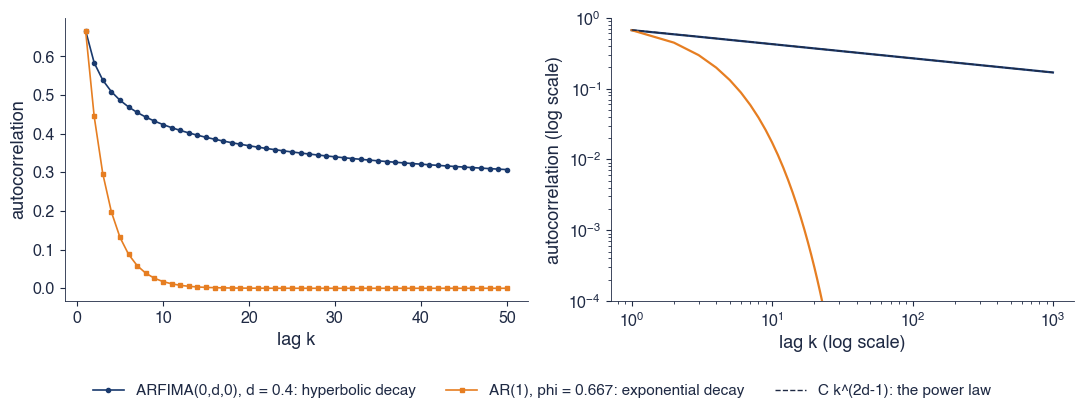

{'d': 0.4, 'phi': 0.6666666666666667, 'r10': 0.42356815660524894, 'r50': 0.30701712214279414, 'r100': 0.26727457002601096, 'r1000': 0.16863898651039302, 'a10': 0.017341529915832633, 'a50': 1.5683285454839674e-09, 'a100': 2.4596544265798566e-18, 'sum100': 33.04295853826425, 'sum1000': 210.38305263125378, 'asum': 2.000000000000001, 'C': 0.6713639030175625}


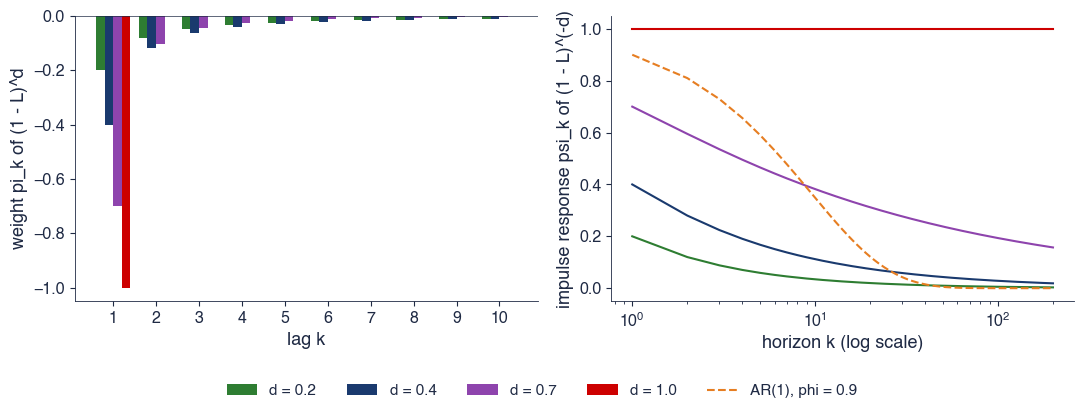

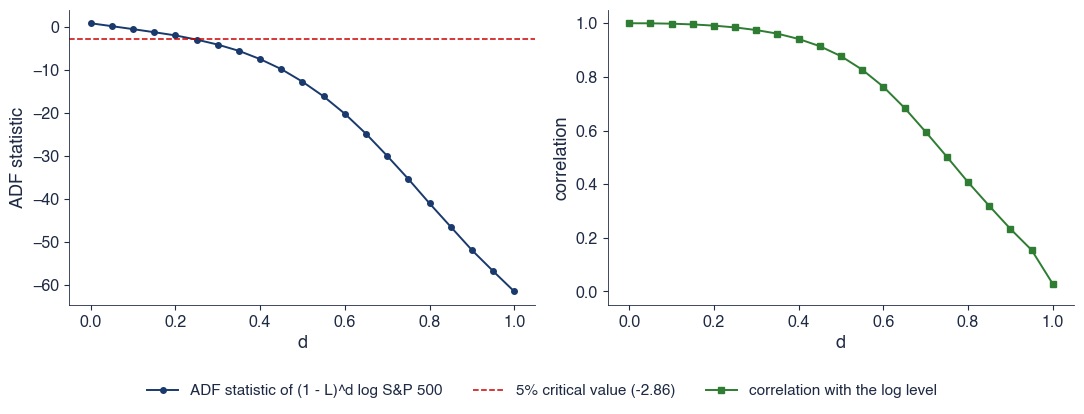

minimal d: 0.25 correlation: 0.984


In [8]:
def worked_examples():
    """Numbers of the worked examples: weights of (1 - L)^0.4, ACF of ARFIMA(0,0.3,0), impulse responses of
    d = 0.7, R/S of eight values."""
    r3 = arfima_acf(0.3, 11)
    psi7 = frac_weights(-0.7, 101)
    return {'w04': frac_weights(0.4, 6).tolist(), 'r03': r3.tolist(), 'v03': float(arfima_acvf0(0.3, 1)[0]),
            'ar_same': float(r3[1] ** 10), 'psi07_10': float(psi7[10]), 'psi07_100': float(psi7[100]),
            'rs': rs_steps(RS_EXAMPLE)}


def fig_decay(d=0.4, save_it=True):
    """ACF of ARFIMA(0,d,0) against an AR(1) with the same lag-1 autocorrelation rho_1 = d / (1 - d)."""
    K = 1000
    r = arfima_acf(d, K + 1)[1:]
    phi = r[0]
    k = np.arange(1, K + 1)
    C = special.gamma(1 - d) / special.gamma(d)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
    ax[0].plot(k[:50], r[:50], 'o-', ms=3, color=st.MainBlue, lw=1.2, label=f'ARFIMA(0,d,0), d = {d}: hyperbolic decay')
    ax[0].plot(k[:50], phi ** k[:50], 's-', ms=3, color=st.Orange, lw=1.2, label=f'AR(1), phi = {phi:.3f}: exponential decay')
    ax[0].set_xlabel('lag k')
    ax[0].set_ylabel('autocorrelation')
    ax[1].loglog(k, r, color=st.MainBlue, lw=1.6, label='_')
    ax[1].loglog(k, phi ** k, color=st.Orange, lw=1.6, label='_')
    ax[1].loglog(k, C * k ** (2 * d - 1), color=st.DarkText, ls='--', lw=1.0, label='C k^(2d-1): the power law')
    ax[1].set_ylim(1e-4, 1)
    ax[1].set_xlabel('lag k (log scale)')
    ax[1].set_ylabel('autocorrelation (log scale)')
    st.fig_legend_bottom(fig, ncol=3, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_decay', save_it)
    return {'d': d, 'phi': float(phi), 'r10': float(r[9]), 'r50': float(r[49]), 'r100': float(r[99]), 'r1000': float(r[-1]),
            'a10': float(phi ** 10), 'a50': float(phi ** 50), 'a100': float(phi ** 100), 'sum100': float(r[:100].sum()),
            'sum1000': float(r.sum()), 'asum': float(phi / (1 - phi)), 'C': float(C)}


def fig_weights(save_it=True):
    """Left: the weights pi_k of (1 - L)^d (fractional differencing); right: the impulse responses psi_k of
    (1 - L)^(-d) (fractional integration) against an AR(1)."""
    ds = [(0.2, st.Forest), (0.4, st.MainBlue), (0.7, st.Purple), (1.0, st.IDAred)]
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
    k = np.arange(0, 11)
    off = {0.2: -0.3, 0.4: -0.1, 0.7: 0.1, 1.0: 0.3}
    out = {}
    for d, c in ds:
        w = frac_weights(d, 11)
        ax[0].bar(k[1:] + off[d], w[1:], width=0.2, color=c, label=f'd = {d}')
        out[str(d)] = {'pi': w[:6].tolist()}
    ax[0].axhline(0, color=st.DarkText, lw=0.5)
    ax[0].set_xlabel('lag k')
    ax[0].set_ylabel('weight pi_k of (1 - L)^d')
    ax[0].set_xticks(k[1:])
    K = 200
    kk = np.arange(1, K + 1)
    for d, c in ds:
        psi = frac_weights(-d, K + 1)[1:]
        ax[1].plot(kk, psi, color=c, lw=1.5, label='_')
        out[str(d)]['psi10'] = float(psi[9])
        out[str(d)]['psi100'] = float(psi[99])
    ax[1].plot(kk, 0.9 ** kk, color=st.Orange, lw=1.5, ls='--', label='AR(1), phi = 0.9')
    ax[1].set_xscale('log')
    ax[1].set_xlabel('horizon k (log scale)')
    ax[1].set_ylabel('impulse response psi_k of (1 - L)^(-d)')
    st.fig_legend_bottom(fig, ncol=5, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_weights', save_it)
    out['ar10'] = float(0.9 ** 10)
    out['ar100'] = float(0.9 ** 100)
    return out


def fig_ffd(save_it=True, thresh=1e-4):
    """Fractional differencing of the log S&P 500 (daily, 2000-2026) with a fixed window (weights above thresh):
    ADF statistic and correlation with the log level against d."""
    p = np.log(load_close('sp500', '2000-01-01')).values
    grid = np.round(np.arange(0, 1.0001, 0.05), 2)
    adf, cor, width = [], [], []
    for d in grid:
        if d == 0:
            y, K = p, 1
        else:
            y = frac_diff(p, d, thresh)
            K = len(p) - len(y) + 1
        adf.append(float(adfuller(y, maxlag=1, regression='c', autolag=None)[0]))
        cor.append(float(np.corrcoef(y, p[K - 1:])[0, 1]))
        width.append(int(K))
    crit = float(adfuller(p, maxlag=1, regression='c', autolag=None)[4]['5%'])
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
    ax[0].plot(grid, adf, 'o-', color=st.MainBlue, lw=1.4, ms=4, label='ADF statistic of (1 - L)^d log S&P 500')
    ax[0].axhline(crit, color=st.IDAred, ls='--', lw=1.1, label=f'5% critical value ({crit:.2f})')
    ax[0].set_xlabel('d')
    ax[0].set_ylabel('ADF statistic')
    ax[1].plot(grid, cor, 's-', color=st.Forest, lw=1.4, ms=4, label='correlation with the log level')
    ax[1].set_xlabel('d')
    ax[1].set_ylabel('correlation')
    ax[1].set_ylim(-0.05, 1.05)
    st.fig_legend_bottom(fig, ncol=3, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_ffd', save_it)
    j = int(np.argmax(np.array(adf) < crit))
    return {'crit': crit, 'dmin': float(grid[j]), 'cor_dmin': cor[j], 'width_dmin': width[j], 'adf0': adf[0], 'adf1': adf[-1],
            'cor1': cor[-1], 'cor0': cor[0], 'n': int(len(p)), 'adf': adf, 'cor': cor, 'grid': grid.tolist()}


print(worked_examples()['w04'])
print(fig_decay(save_it=False))
fig_weights(save_it=False)
ff = fig_ffd(save_it=False)
print('minimal d:', ff['dmin'], 'correlation:', round(ff['cor_dmin'], 3))

## 3. ARFIMA processes, fBm and fGn

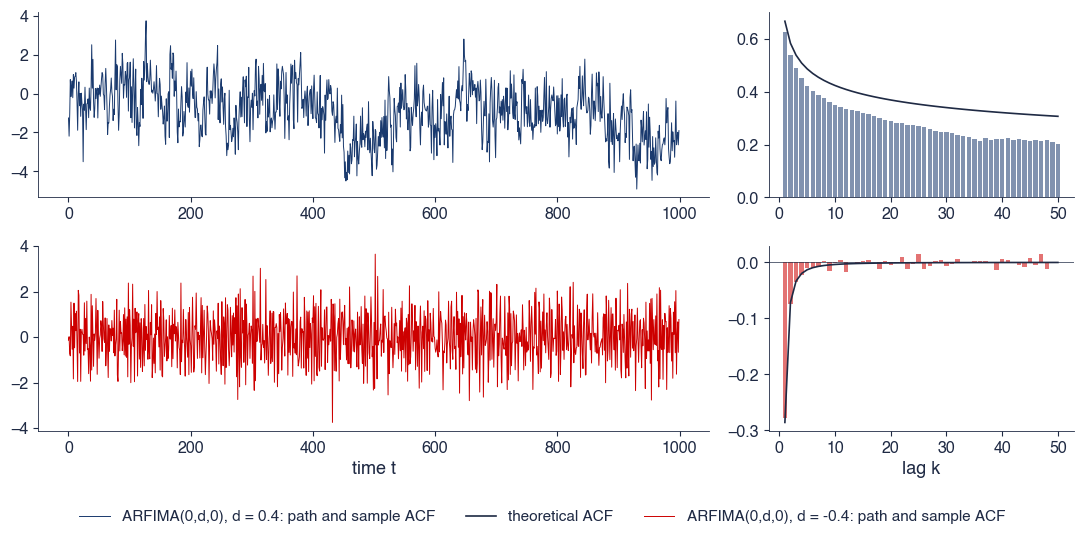

{'0.4': {'rho1': 0.6666666666666667, 'rho2': 0.5833333333333333, 'rho10': 0.42356815660524894, 'rho50': 0.30701712214279414, 'sd': 1.3667219615958022, 'var_th': 2.0700983252962857}, '-0.4': {'rho1': -0.2857142857142857, 'rho2': -0.07142857142857142, 'rho10': -0.0037834857922467422, 'rho50': -0.00020847077132197319, 'sd': 1.0936915501898756, 'var_th': 1.183104546842922}}


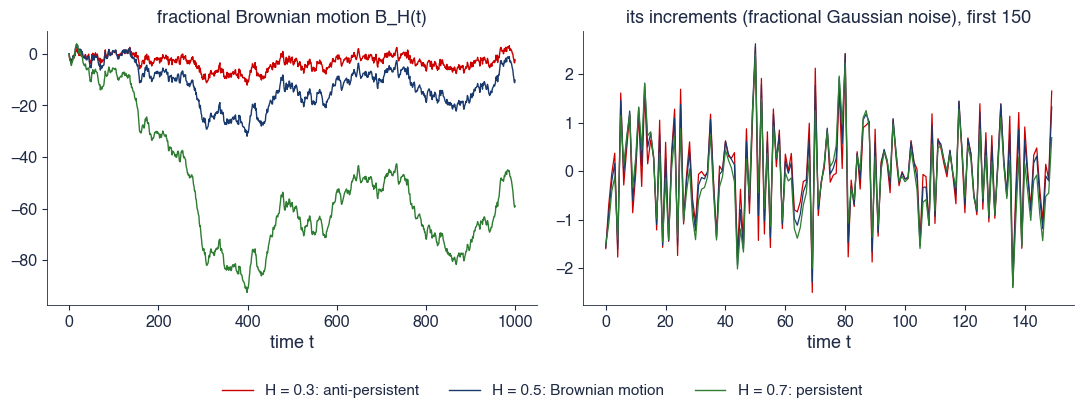

{'0.3': {'acf1': -0.2326279009381103, 'acf1_th': -0.242141716744801}, '0.5': {'acf1': 0.012819580734563804, 'acf1_th': 0.0}, '0.7': {'acf1': 0.31605443535403394, 'acf1_th': 0.3195079107728942}}


In [9]:
def fig_arfima_paths(n=1000, ds=(0.4, -0.4), nlags=50, save_it=True):
    """ARFIMA(0,d,0) paths and ACF for d = 0.4 and d = -0.4, Gaussian white noise N(0, 1)."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 5.2), gridspec_kw={'width_ratios': [2.2, 1]})
    k = np.arange(1, nlags + 1)
    out = {}
    for row, (d, c) in enumerate(zip(ds, [st.MainBlue, st.IDAred])):
        x = sim_arfima(n, d, np.random.default_rng(SEED + 7 + row))[0]
        axes[row, 0].plot(np.arange(n), x, color=c, lw=0.7, label=f'ARFIMA(0,d,0), d = {d}: path and sample ACF')
        th = arfima_acf(d, nlags + 1)[1:]
        xl = sim_arfima(20000, d, np.random.default_rng(SEED + 17 + row))[0]
        axes[row, 1].bar(k, acf(xl, nlags), color=c, alpha=0.55, width=0.8, label='_')
        axes[row, 1].plot(k, th, color=st.DarkText, lw=1.2, label='theoretical ACF' if row == 0 else '_')
        axes[row, 1].axhline(0, color=st.DarkText, lw=0.5)
        out[str(d)] = {'rho1': float(th[0]), 'rho2': float(th[1]), 'rho10': float(th[9]), 'rho50': float(th[49]),
                       'sd': float(x.std()), 'var_th': float(arfima_acvf0(d, 1)[0])}
    axes[1, 0].set_xlabel('time t')
    axes[1, 1].set_xlabel('lag k')
    st.fig_legend_bottom(fig, ncol=3, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_arfima_paths', save_it)
    return out


def fig_fbm(n=1000, Hs=(0.3, 0.5, 0.7), save_it=True):
    """Fractional Brownian motion paths for three Hurst exponents (the same random numbers) and their increments."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    out = {}
    for H, c in zip(Hs, [st.IDAred, st.MainBlue, st.Forest]):
        x = sim_fgn(n, H, np.random.default_rng(SEED))[0]
        b = np.concatenate([[0], np.cumsum(x)])
        lab = {0.5: 'H = 0.5: Brownian motion'}.get(H, f'H = {H}: ' + ('anti-persistent' if H < 0.5 else 'persistent'))
        axes[0].plot(np.arange(n + 1), b, color=c, lw=1.0, label=lab)
        axes[1].plot(np.arange(150), x[:150], color=c, lw=0.9, label='_')
        out[str(H)] = {'acf1': float(acf(x, 1)[0]), 'acf1_th': float(2 ** (2 * H - 1) - 1)}
    axes[0].set_title('fractional Brownian motion B_H(t)')
    axes[1].set_title('its increments (fractional Gaussian noise), first 150')
    for a in axes:
        a.set_xlabel('time t')
    st.fig_legend_bottom(fig, ncol=3, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_fbm', save_it)
    return out


print(fig_arfima_paths(save_it=False))
print(fig_fbm(save_it=False))

## 4. Estimating d

- R/S and DFA; GPH; local Whittle and the bandwidth; exact ML against ARMA; the table of twelve series.

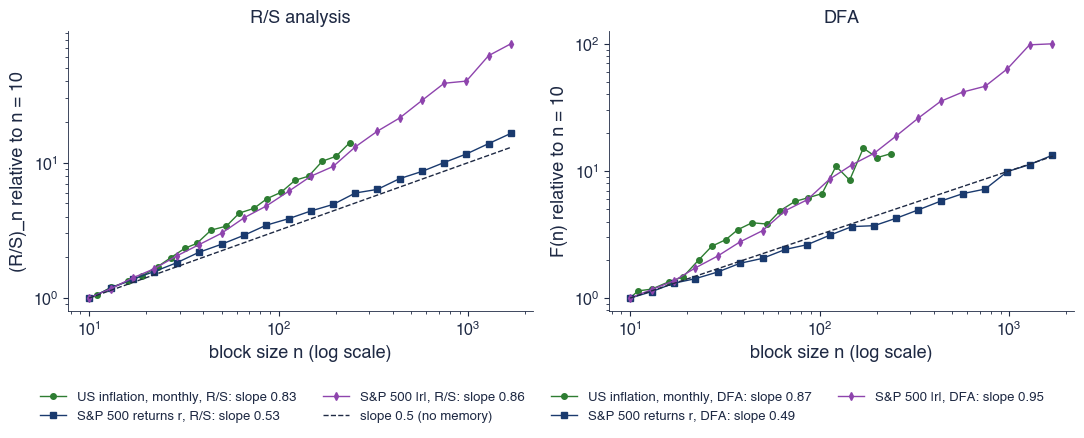

{'rs|US inflation, monthly': 0.8318681684199807, 'dfa|US inflation, monthly': 0.8739706499760628, 'rs|S&P 500 returns r': 0.5304720271599298, 'dfa|S&P 500 returns r': 0.4883266595754514, 'rs|S&P 500 |r|': 0.8613572566975962, 'dfa|S&P 500 |r|': 0.95338823549873}


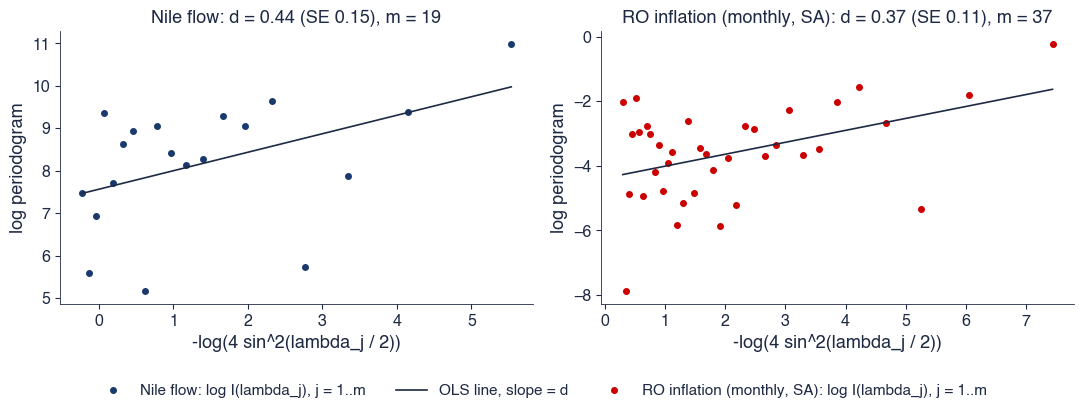

{'nile': {'d': 0.4354042891755117, 'se': 0.1471185552560742, 'm': 19, 'T': 100, 'lam_m': 1.1938052083641213, 'period_m': 5.2631578947368425, 'lw': 0.40297109014126853, 'lw_se': 0.11470786693528087}, 'infl': {'d': 0.3692378502579654, 'se': 0.10542494662363422, 'm': 37, 'T': 260, 'lam_m': 0.8941456014063257, 'period_m': 7.027027027027027, 'lw': 0.30630024351880936, 'lw_se': 0.08219949365267865}}


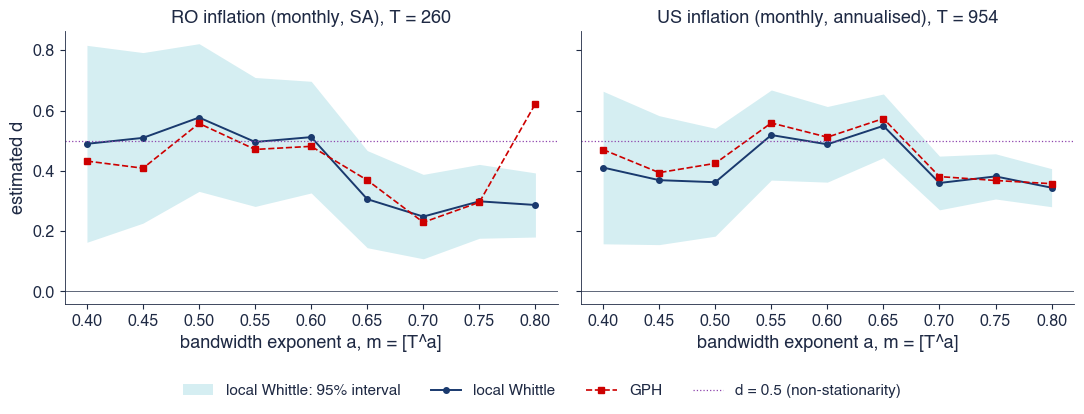

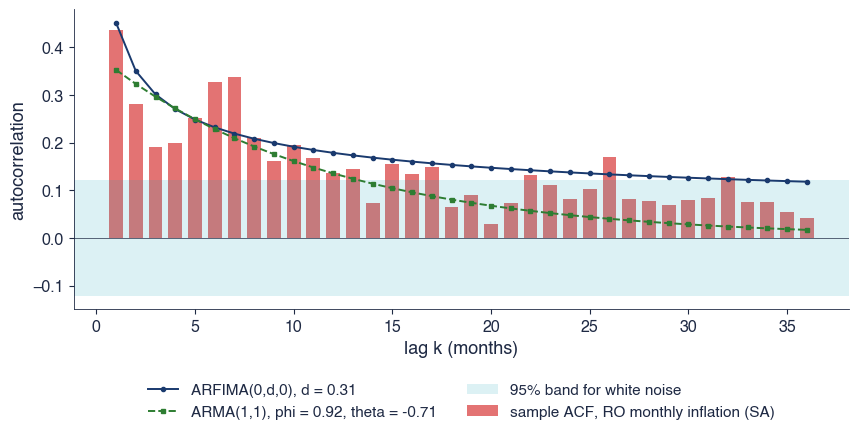

            name      d   loglik      aic      bic
0      ARMA(1,1)  0.000 -138.038  282.076  292.758
1      ARMA(2,0)  0.000 -139.939  285.877  296.559
2  ARFIMA(0,d,0)  0.311 -135.876  275.752  282.873
3  ARFIMA(1,d,0)  0.269 -135.561  277.123  287.805
4  ARFIMA(0,d,1)  0.270 -135.540  277.080  287.762
5  ARFIMA(1,d,1)  0.272 -135.538  279.077  293.320


                             n        rs       dfa       gph        lw  \
Nile flow                  100  0.832301  0.642546  0.435404  0.402971   
RO inflation, monthly SA   260   0.74727   0.83769  0.369238    0.3063   
RO inflation, 12-month     260  0.956065  1.382444  1.144083  1.003934   
US inflation, monthly      954  0.831868  0.873971  0.573687  0.549475   
US inflation, 1985-2019    420  0.691801  0.594439  0.066986  0.096447   
US unemployment            944  0.972766  1.269621  0.818221  0.906929   
US unemployment, change    943  0.757588  0.435858 -0.179859 -0.086912   
S&P 500 r                 6714  0.530472  0.488327  0.020366 -0.013419   
S&P 500 |r|               6714  0.861357  0.953388  0.556101  0.530589   
BET r                     6670  0.578108  0.569573  0.160609  0.117702   
BET |r|                   6670   0.78563  0.853724  0.398039  0.386816   
EUR/RON r                 5352  0.532741  0.521598  -0.00959 -0.005809   
EUR/RON |r|               5352  0.8239

In [10]:
def fig_rs_dfa(save_it=True):
    """R/S and DFA log-log plots for US monthly inflation, S&P 500 daily returns and absolute returns."""
    r = returns('sp500').values
    S = [('US inflation, monthly', us_inflation().values, st.Forest, 'o'), ('S&P 500 returns r', r, st.MainBlue, 's'),
         ('S&P 500 |r|', np.abs(r), st.Purple, 'd')]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
    out = {}
    for name, x, c, m in S:
        sizes = block_sizes(len(x))
        for ax, f, key in [(axes[0], rs_curve, 'rs'), (axes[1], dfa_curve, 'dfa')]:
            n, v = f(x, sizes)
            sl = float(np.polyfit(np.log10(n), np.log10(v), 1)[0])
            ax.loglog(n, v / v[0], m + '-', ms=4, lw=1.0, color=c, label=f'{name}: slope {sl:.2f}')
            out[f'{key}|{name}'] = sl
    nn = np.array([10, 1700])
    for ax in axes:
        ax.loglog(nn, (nn / 10) ** 0.5, color=st.DarkText, ls='--', lw=1.0, label='slope 0.5 (no memory)')
        ax.set_xlabel('block size n (log scale)')
    axes[0].set_ylabel('(R/S)_n relative to n = 10')
    axes[1].set_ylabel('F(n) relative to n = 10')
    axes[0].set_title('R/S analysis')
    axes[1].set_title('DFA')
    handles, labels = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig.legend(handles + h2[:-1], [l.replace(':', ', R/S:') for l in labels[:-1]] + [labels[-1]] + [l.replace(':', ', DFA:') for l in l2[:-1]],
               loc='upper center', bbox_to_anchor=(0.5, 0.03), ncol=4, frameon=False, fontsize=9.5)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_rs_dfa', save_it)
    return out


def fig_gph(save_it=True):
    """The GPH log-periodogram regression: the Nile and Romanian monthly inflation."""
    S = [('nile', nile().values), ('infl', ro_inflation().values)]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    out = {}
    for ax, (k, x) in zip(axes, S):
        lam, I = periodogram(x)
        g = gph(x)
        m = g['m']
        X = -np.log(4 * np.sin(lam[:m] / 2) ** 2)
        ax.plot(X, np.log(I[:m]), 'o', ms=4, color=COLORS[k], label=f'{NAME[k]}: log I(lambda_j), j = 1..m')
        b = np.polyfit(X, np.log(I[:m]), 1)
        xx = np.linspace(X.min(), X.max(), 50)
        ax.plot(xx, np.polyval(b, xx), color=st.DarkText, lw=1.2, label='OLS line, slope = d' if k == 'nile' else '_')
        ax.set_title(f"{NAME[k]}: d = {g['d']:.2f} (SE {g['se']:.2f}), m = {m}")
        ax.set_xlabel('-log(4 sin^2(lambda_j / 2))')
        ax.set_ylabel('log periodogram')
        out[k] = dict(g, T=int(len(x)), lam_m=float(lam[m - 1]), period_m=float(2 * np.pi / lam[m - 1]),
                      lw=local_whittle(x)['d'], lw_se=local_whittle(x)['se'])
    st.fig_legend_bottom(fig, ncol=3, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_gph', save_it)
    return out


def fig_bandwidth(save_it=True):
    """GPH and local Whittle estimates of d against the bandwidth m = [T^a], a = 0.4..0.8, with 95% intervals of LW."""
    S = [('infl', ro_inflation().values), ('usinfl', us_inflation().values)]
    A = np.round(np.arange(0.40, 0.801, 0.05), 2)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
    out = {}
    for ax, (k, x) in zip(axes, S):
        T = len(x)
        G = [gph(x, bandwidth(T, a)) for a in A]
        W = [local_whittle(x, bandwidth(T, a)) for a in A]
        lw = np.array([w['d'] for w in W])
        se = np.array([w['se'] for w in W])
        ax.fill_between(A, lw - 1.96 * se, lw + 1.96 * se, color=st.Teal, alpha=0.18, lw=0,
                        label='local Whittle: 95% interval' if k == 'infl' else '_')
        ax.plot(A, lw, 'o-', color=st.MainBlue, lw=1.4, ms=4, label='local Whittle' if k == 'infl' else '_')
        ax.plot(A, [g['d'] for g in G], 's--', color=st.IDAred, lw=1.2, ms=4, label='GPH' if k == 'infl' else '_')
        ax.axhline(0, color=st.DarkText, lw=0.5)
        ax.axhline(0.5, color=st.Purple, lw=0.9, ls=':', label='d = 0.5 (non-stationarity)' if k == 'infl' else '_')
        ax.set_title(f'{NAME[k]}, T = {T}')
        ax.set_xlabel('bandwidth exponent a, m = [T^a]')
        out[k] = {'T': T, 'a': A.tolist(), 'lw': lw.tolist(), 'gph': [g['d'] for g in G], 'm': [w['m'] for w in W]}
    axes[0].set_ylabel('estimated d')
    st.fig_legend_bottom(fig, ncol=4, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_bandwidth', save_it)
    return out


def model_table(x, specs=((1, 1, 0.0), (2, 0, 0.0), (0, 0, None), (1, 0, None), (0, 1, None), (1, 1, None))):
    """Exact ML of ARMA models (d fixed at 0) and ARFIMA models on the same series: log-likelihood, AIC, BIC."""
    out = []
    for p, q, fd in specs:
        r = arfima_exact_ml(x, p, q, fix_d=fd)
        r['name'] = f'ARMA({p},{q})' if fd is not None else f'ARFIMA({p},d,{q})'
        out.append(r)
    return out


def fig_arfima_fit(save_it=True, L=36):
    """Romanian monthly inflation: sample ACF, the ACF of the fitted ARFIMA(0,d,0) and ARMA(1,1) (exact ML)."""
    x = ro_inflation().values
    tab = model_table(x)
    fd = next(r for r in tab if r['name'] == 'ARFIMA(0,d,0)')
    fa = next(r for r in tab if r['name'] == 'ARMA(1,1)')
    k = np.arange(1, L + 1)
    r = acf(x, L)
    gd = arfima_acvf(fd['d'], [], [], 1, L + 1)
    ga = arfima_acvf(0.0, fa['phi'], fa['theta'], 1, L + 1)
    fig, ax = plt.subplots(figsize=(10, 3.9))
    ax.bar(k, r, color=COLORS['infl'], alpha=0.55, width=0.7, label='sample ACF, RO monthly inflation (SA)')
    ax.plot(k, gd[1:] / gd[0], 'o-', ms=3, color=st.MainBlue, lw=1.4, label=f"ARFIMA(0,d,0), d = {fd['d']:.2f}")
    ax.plot(k, ga[1:] / ga[0], 's--', ms=3, color=st.Forest, lw=1.4,
            label=f"ARMA(1,1), phi = {fa['phi'][0]:.2f}, theta = {fa['theta'][0]:.2f}")
    band = 1.96 / np.sqrt(len(x))
    ax.axhspan(-band, band, color=st.Teal, alpha=0.15, lw=0, label='95% band for white noise')
    ax.axhline(0, color=st.DarkText, lw=0.5)
    ax.set_xlabel('lag k (months)')
    ax.set_ylabel('autocorrelation')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('tsa_ch8_arfima_fit', save_it)
    for t in tab:
        t.pop('se', None)
    return {'T': int(len(x)), 'table': tab, 'r12': float(r[11]), 'r24': float(r[23]), 'd12': float(gd[12] / gd[0]),
            'a12': float(ga[12] / ga[0]), 'd24': float(gd[24] / gd[0]), 'a24': float(ga[24] / ga[0])}


def memory_table():
    """All estimators for the series of the chapter."""
    S = {'Nile flow': nile().values, 'RO inflation, monthly SA': ro_inflation().values,
         'RO inflation, 12-month': ro_inflation12().values, 'US inflation, monthly': us_inflation().values,
         'US inflation, 1985-2019': us_inflation('1985-01-01', '2019-12-01').values,
         'US unemployment': us_unemployment().values, 'US unemployment, change': us_unemployment().diff().dropna().values}
    for k in ('sp500', 'bet', 'eurron'):
        r = returns(k)
        S[f'{NAME[k]} r'] = r.values
        S[f'{NAME[k]} |r|'] = np.abs(r.values)
    out = {k: all_estimates(v) for k, v in S.items()}
    pd.DataFrame(out).T.to_csv(os.path.join(HERE, 'ch8_memory_table.csv'), float_format='%.4f')
    return out


print(fig_rs_dfa(save_it=False))
print(fig_gph(save_it=False))
fig_bandwidth(save_it=False)
fit = fig_arfima_fit(save_it=False)
print(pd.DataFrame(fit['table'])[['name', 'd', 'loglik', 'aic', 'bic']].round(3))
print(pd.DataFrame(memory_table()).T[['n', 'rs', 'dfa', 'gph', 'lw', 'lw_se']].round(2))

## 5. Monte Carlo of the estimators

- 300 samples per design; it takes a few minutes. Reduce `reps` to go faster.

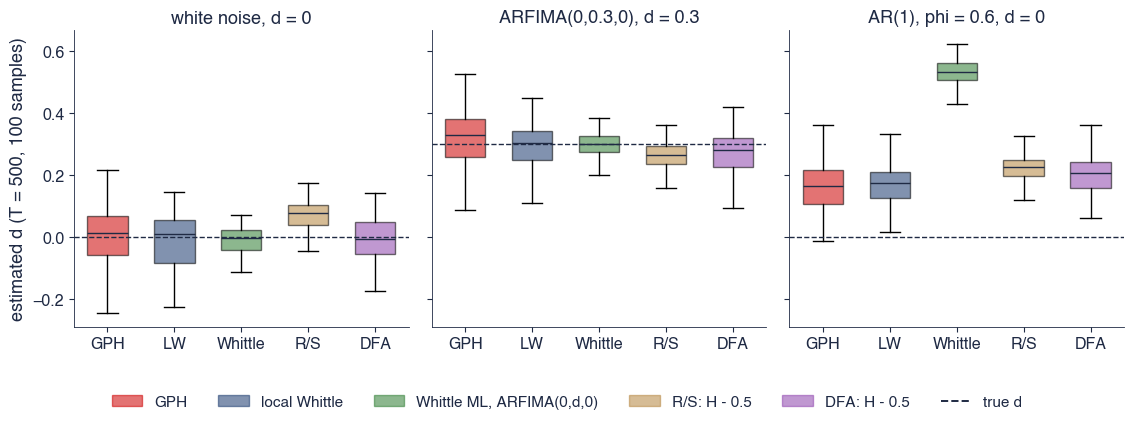

{'white noise, d = 0': {'GPH': -0.004, 'LW': -0.007, 'Whittle': -0.007, 'R/S': 0.073, 'DFA': -0.006}, 'ARFIMA(0,0.3,0), d = 0.3': {'GPH': 0.314, 'LW': 0.294, 'Whittle': 0.299, 'R/S': 0.266, 'DFA': 0.277}, 'AR(1), phi = 0.6, d = 0': {'GPH': 0.167, 'LW': 0.169, 'Whittle': 0.535, 'R/S': 0.227, 'DFA': 0.208}}


In [11]:
def fig_mc(T=500, reps=MC_REPS, save_it=True):
    """Monte Carlo of five estimators of d (GPH, local Whittle, Whittle ML of ARFIMA(0,d,0), R/S and DFA with
    d = H - 0.5) for three designs: white noise (d = 0), ARFIMA(0,0.3,0), AR(1) with phi = 0.6 (d = 0)."""
    designs = [('white noise, d = 0', 0.0, None), ('ARFIMA(0,0.3,0), d = 0.3', 0.3, None), ('AR(1), phi = 0.6, d = 0', 0.0, 0.6)]
    names = ['GPH', 'LW', 'Whittle', 'R/S', 'DFA']
    rng = np.random.default_rng(SEED + 41)
    sizes = block_sizes(T)
    res = {}
    for lab, d, phi in designs:
        if phi is None:
            X = sim_arfima(T, d, rng, size=reps)
        else:
            e = rng.standard_normal((reps, T + 200))
            X = np.zeros_like(e)
            for t in range(1, T + 200):
                X[:, t] = phi * X[:, t - 1] + e[:, t]
            X = X[:, 200:]
        est = {n: [] for n in names}
        for x in X:
            est['GPH'].append(gph(x)['d'])
            est['LW'].append(local_whittle(x)['d'])
            est['Whittle'].append(arfima_whittle(x)['d'])
            est['R/S'].append(hurst_rs(x, sizes) - 0.5)
            est['DFA'].append(hurst_dfa(x, sizes) - 0.5)
        res[lab] = {'d': d, **{n: {'mean': float(np.mean(v)), 'sd': float(np.std(v)),
                                   'rmse': float(np.sqrt(np.mean((np.array(v) - d) ** 2))), 'v': v} for n, v in est.items()}}
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.9), sharey=True)
    cols = [st.IDAred, st.MainBlue, st.Forest, st.Amber, st.Purple]
    for ax, (lab, d, phi) in zip(axes, designs):
        b = ax.boxplot([res[lab][n]['v'] for n in names], patch_artist=True, widths=0.6, showfliers=False)
        for patch, c in zip(b['boxes'], cols):
            patch.set_facecolor(c)
            patch.set_alpha(0.55)
        for med in b['medians']:
            med.set_color(st.DarkText)
        ax.axhline(d, color=st.DarkText, ls='--', lw=1.0)
        ax.set_xticks(range(1, len(names) + 1))
        ax.set_xticklabels(names)
        ax.set_title(lab)
    axes[0].set_ylabel(f'estimated d (T = {T}, {reps} samples)')
    from matplotlib.patches import Patch
    st.fig_legend_bottom(fig, handles=[Patch(color=c, alpha=0.55) for c in cols] + [plt.Line2D([], [], color=st.DarkText, ls='--')],
                         labels=['GPH', 'local Whittle', 'Whittle ML, ARFIMA(0,d,0)', 'R/S: H - 0.5', 'DFA: H - 0.5', 'true d'],
                         ncol=6, y=0.0)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_mc', save_it)
    for lab in res:
        for n in names:
            res[lab][n].pop('v')
    return {'T': T, 'reps': reps, 'res': res}


mc = fig_mc(reps=100, save_it=False)
print({lab: {k: round(v[k]['mean'], 3) for k in ['GPH', 'LW', 'Whittle', 'R/S', 'DFA']} for lab, v in mc['res'].items()})

## 6. Forecasting with ARFIMA

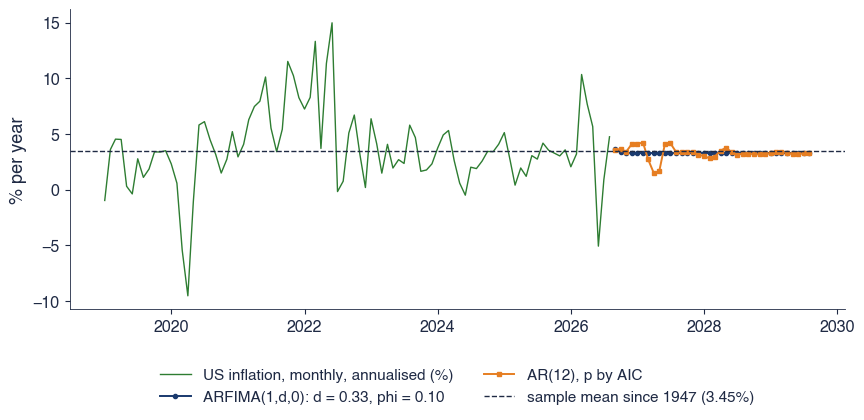

{'d': 0.33478586570784774, 'phi': np.float64(0.10312669433927471), 'p': 12, 'mean': 3.4520891346018594, 'last': 4.742833158009674, 'last_d': '2026-08-01', 'fa1': 3.6164500133124386, 'fa12': 3.284961095455339, 'fa36': 3.2856964476537645, 'fr1': 3.5884265015410852, 'fr12': 3.382578843701511, 'fr36': 3.256338466761272, 'T': 954, 'm12': 3.645687906705497}


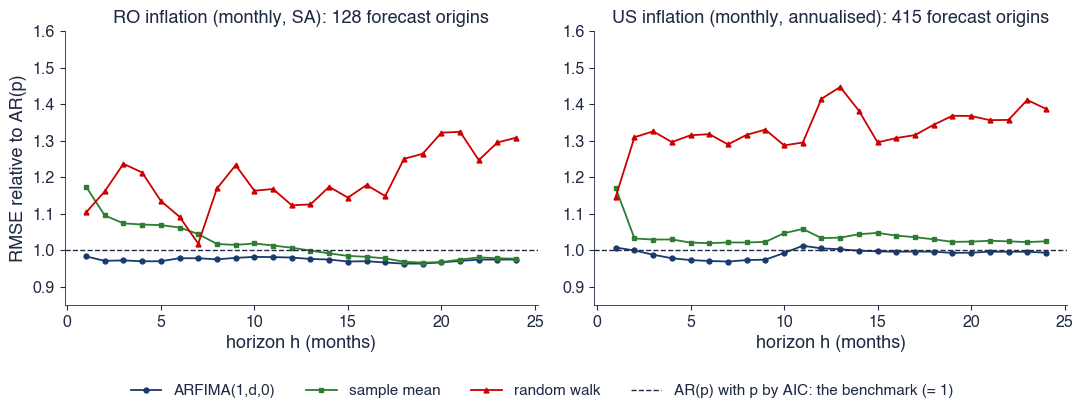

{'ro': [0.983, 0.978, 0.976, 0.963], 'us': [1.007, 0.969, 1.002, 0.992]}


In [12]:
def fig_forecast_path(save_it=True, H=36):
    """Forecasts of US monthly inflation from the last observation: ARFIMA(1,d,0) (Whittle) and AR(p), with the
    sample mean."""
    y = us_inflation()
    x = y.values
    e = arfima_whittle(x, 1, 0)
    fa = arfima_forecast(x, e['d'], e['phi'], [], H)
    fr, p = ar_forecast(x, H)
    fut = pd.date_range(y.index[-1], periods=H + 1, freq='MS')[1:]
    hist = y.loc['2019-01-01':]
    fig, ax = plt.subplots(figsize=(10, 3.9))
    ax.plot(hist.index, hist.values, color=COLORS['usinfl'], lw=1.0, label='US inflation, monthly, annualised (%)')
    ax.plot(fut, fa, 'o-', ms=3, color=st.MainBlue, lw=1.4, label=f"ARFIMA(1,d,0): d = {e['d']:.2f}, phi = {e['phi'][0]:.2f}")
    ax.plot(fut, fr, 's-', ms=3, color=st.Orange, lw=1.4, label=f'AR({p}), p by AIC')
    ax.axhline(x.mean(), color=st.DarkText, ls='--', lw=1.0, label=f'sample mean since 1947 ({x.mean():.2f}%)')
    ax.set_ylabel('% per year')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('tsa_ch8_forecast_path', save_it)
    return {'d': e['d'], 'phi': e['phi'][0], 'p': p, 'mean': float(x.mean()), 'last': float(x[-1]),
            'last_d': y.index[-1].date().isoformat(), 'fa1': float(fa[0]), 'fa12': float(fa[11]), 'fa36': float(fa[-1]),
            'fr1': float(fr[0]), 'fr12': float(fr[11]), 'fr36': float(fr[-1]), 'T': int(len(x)),
            'm12': float(np.mean(x[-12:]))}


def fig_forecast(save_it=True, H=24):
    """Pseudo out-of-sample RMSE relative to the AR(p) benchmark, by horizon: Romanian monthly inflation (seasonal
    adjustment inside each window) and US monthly inflation."""
    raw = (100 * np.log(ro_hicp()).diff()).dropna().loc[INFL_START:]
    ro = oos_inflation(raw, '2014-01-01', H, seasonal=True)
    us = oos_inflation(us_inflation(), '1990-01-01', H)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    h = np.arange(1, H + 1)
    for ax, (k, R) in zip(axes, [('infl', ro), ('usinfl', us)]):
        base = np.array(R['rmse']['AR'])
        for m, c, mk in [('ARFIMA', st.MainBlue, 'o'), ('Mean', st.Forest, 's'), ('RW', st.IDAred, '^')]:
            ax.plot(h, np.array(R['rmse'][m]) / base, mk + '-', ms=3.5, color=c, lw=1.3,
                    label={'ARFIMA': 'ARFIMA(1,d,0)', 'Mean': 'sample mean', 'RW': 'random walk'}[m] if k == 'infl' else '_')
        ax.axhline(1, color=st.DarkText, ls='--', lw=1.0, label='AR(p) with p by AIC: the benchmark (= 1)' if k == 'infl' else '_')
        ax.set_title(f"{NAME[k]}: {R['n']} forecast origins")
        ax.set_xlabel('horizon h (months)')
        ax.set_ylim(0.85, 1.6)
    axes[0].set_ylabel('RMSE relative to AR(p)')
    st.fig_legend_bottom(fig, ncol=4, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_forecast', save_it)
    return {'ro': ro, 'us': us}


print(fig_forecast_path(save_it=False))
fc = fig_forecast(save_it=False)
print({k: [round(a / b, 3) for a, b in zip(fc[k]['rmse']['ARFIMA'][::6], fc[k]['rmse']['AR'][::6])] for k in ('ro', 'us')})

## 7. Long memory in volatility

- ACF of $r$, $|r|$, $r^2$; realised volatility; GARCH against FIGARCH; HAR.

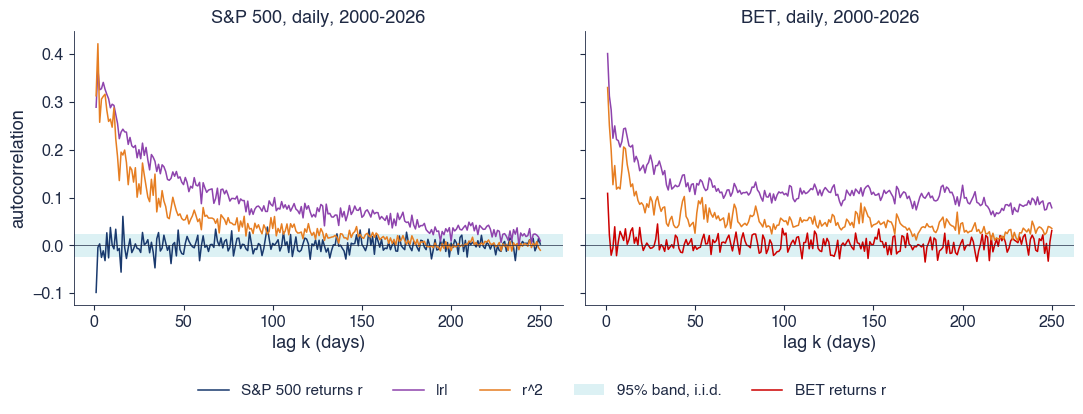

{'sp500': (0.53, 0.0), 'bet': (0.39, -0.02)}


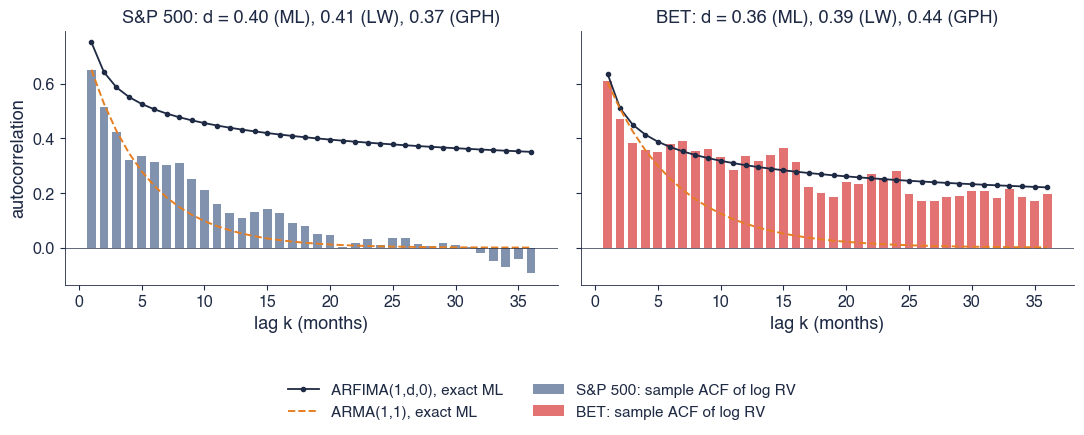

{'sp500': {'T': 321, 'lw': 0.4069449865374172, 'lw_se': 0.07715167498104596, 'gph': 0.3733465607607188, 'gph_se': 0.09895086764364382, 'ml': 0.3976946933704396, 'ml_se': 0.0777336356504567, 'ml_phi': 0.14259691067617197, 'bic_f': np.float64(295.9043673348441), 'bic_a': np.float64(294.3878495254228), 'a_phi': 0.8096974948599285, 'a_theta': -0.2856582539360995, 'r1': 0.649354803141801, 'r12': 0.1258708414440958, 'r24': 0.010169831346165708, 'r36': -0.09312068696646186, 'f12': 0.43871689355206767, 'a12': 0.06382306249844961, 'f24': 0.38062652810589304, 'a24': 0.005068170152163187}, 'bet': {'T': 321, 'lw': 0.39135931219049513, 'lw_se': 0.07715167498104596, 'gph': 0.43746110033523317, 'gph_se': 0.09895086764364382, 'ml': 0.35740738548500267, 'ml_se': 0.06306865121966422, 'ml_phi': 0.10075528090795005, 'bic_f': np.float64(343.89093833358254), 'bic_a': np.float64(355.4497212762999), 'a_phi': 0.8390318148595133, 'a_theta': -0.3924596709669448, 'r1': 0.6094265444787051, 'r12': 0.336102126090117

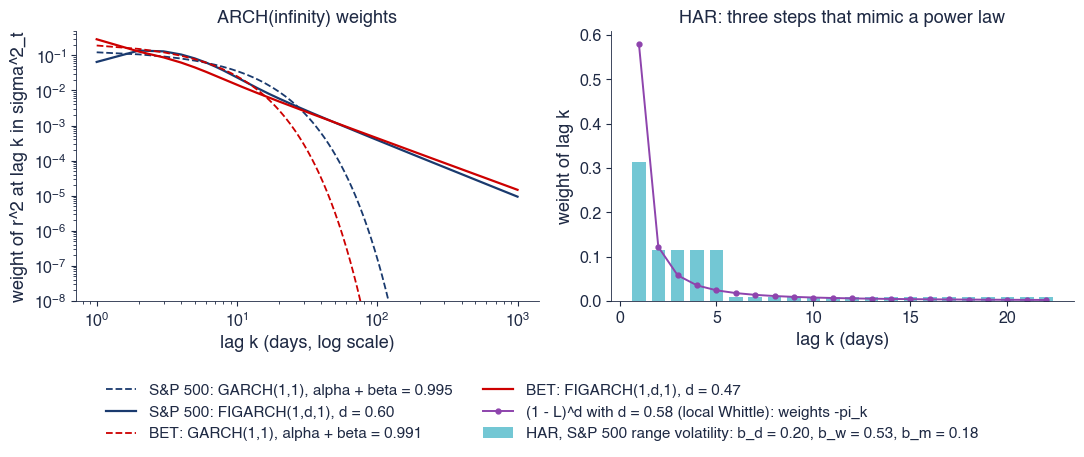

{'d': 0.6046664259914154, 'phi': 0.0316793298984818, 'beta': 0.5712314762302205, 'll': -9040.952104009863, 'bic': 18134.775909084965, 'nu': 6.227727295518504} {'c': 0.06584104420553996, 'bd': 0.19843179939532707, 'bw': 0.53314737970377, 'bm': 0.18232883737397887, 'sum': 0.913908016473076, 'w1': 0.31334894976217104, 'w2': 0.11491715036684395, 'w6': 0.008287674426089948, 'd': 0.5801928974375429, 'n': 6696}


In [13]:
def fig_vol_acf(nlags=250, save_it=True):
    """ACF of r, |r| and r^2 up to lag 250 for the S&P 500 and the BET (Ding, Granger and Engle 1993)."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
    out = {}
    lags = np.arange(1, nlags + 1)
    for ax, k in zip(axes, ('sp500', 'bet')):
        r = returns(k)
        x = r.values
        band = 1.96 / np.sqrt(len(x))
        out[k] = {'n': int(len(x)), 'band': float(band), 'y0': int(r.index[0].year), 'y1': int(r.index[-1].year)}
        for y, c, nm in [(x, COLORS[k], 'returns r'), (np.abs(x), st.Purple, '|r|'), (x ** 2, st.Orange, 'r^2')]:
            a = acf(y, nlags)
            ax.plot(lags, a, color=c, lw=1.1, label=(f'{NAME[k]} returns r' if nm == 'returns r' else nm) if (k == 'sp500' or nm == 'returns r') else '_')
            out[k][nm.split()[0]] = {'1': float(a[0]), '10': float(a[9]), '100': float(a[99]), '250': float(a[249]),
                                     'npos': int(np.sum(a > band))}
        ax.axhspan(-band, band, color=st.Teal, alpha=0.15, lw=0, label='95% band, i.i.d.' if k == 'sp500' else '_')
        ax.axhline(0, color=st.DarkText, lw=0.5)
        ax.set_title(f'{NAME[k]}, daily, {r.index[0].year}-{r.index[-1].year}')
        ax.set_xlabel('lag k (days)')
        rng = np.random.default_rng(SEED + 9)
        out[k]['abs_lw'] = local_whittle(np.abs(x))['d']
        out[k]['abs_shuf_lw'] = local_whittle(rng.permutation(np.abs(x)))['d']
        out[k]['r_lw'] = local_whittle(x)['d']
    axes[0].set_ylabel('autocorrelation')
    st.fig_legend_bottom(fig, ncol=5, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_vol_acf', save_it)
    return out


def fig_rv(save_it=True, L=36):
    """Monthly log realised volatility of the S&P 500 and the BET: sample ACF against the ACF of ARFIMA(1,d,0) and of
    ARMA(1,1), both estimated by exact ML; BIC of the two models."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
    out = {}
    k_ = np.arange(1, L + 1)
    for ax, k in zip(axes, ('sp500', 'bet')):
        x = monthly_rv(k).values
        lw, g = local_whittle(x), gph(x)
        mf = arfima_exact_ml(x, 1, 0)
        ma = arfima_exact_ml(x, 1, 1, fix_d=0.0)
        r = acf(x, L)
        gf = arfima_acvf(mf['d'], mf['phi'], [], 1, L + 1)
        ga = arfima_acvf(0.0, ma['phi'], ma['theta'], 1, L + 1)
        ax.bar(k_, r, color=COLORS[k], alpha=0.55, width=0.7, label=f'{NAME[k]}: sample ACF of log RV')
        ax.plot(k_, gf[1:] / gf[0], 'o-', ms=3, color=st.DarkText, lw=1.3, label='ARFIMA(1,d,0), exact ML' if k == 'sp500' else '_')
        ax.plot(k_, ga[1:] / ga[0], '--', color=st.Orange, lw=1.4, label='ARMA(1,1), exact ML' if k == 'sp500' else '_')
        ax.axhline(0, color=st.DarkText, lw=0.5)
        ax.set_title(f"{NAME[k]}: d = {mf['d']:.2f} (ML), {lw['d']:.2f} (LW), {g['d']:.2f} (GPH)")
        ax.set_xlabel('lag k (months)')
        out[k] = {'T': int(len(x)), 'lw': lw['d'], 'lw_se': lw['se'], 'gph': g['d'], 'gph_se': g['se'], 'ml': mf['d'],
                  'ml_se': mf['se_d'], 'ml_phi': mf['phi'][0], 'bic_f': mf['bic'], 'bic_a': ma['bic'], 'a_phi': ma['phi'][0],
                  'a_theta': ma['theta'][0], 'r1': float(r[0]), 'r12': float(r[11]), 'r24': float(r[23]), 'r36': float(r[-1]),
                  'f12': float(gf[12] / gf[0]), 'a12': float(ga[12] / ga[0]), 'f24': float(gf[24] / gf[0]), 'a24': float(ga[24] / ga[0])}
    axes[0].set_ylabel('autocorrelation')
    st.fig_legend_bottom(fig, ncol=2, y=0.03)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    save('tsa_ch8_rv', save_it)
    return out


def fig_vol_models(save_it=True):
    """Left: ARCH(infinity) weights of GARCH(1,1) and FIGARCH(1,d,1) estimated on S&P 500 and BET returns (Student t);
    right: the lag weights implied by a HAR model (Corsi 2009) for the daily Parkinson range volatility of the S&P 500
    against the AR(infinity) weights of (1 - L)^d."""
    from arch import arch_model
    out = {}
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    for k in ('sp500', 'bet'):
        c = COLORS[k]
        r = returns(k)
        g = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t').fit(disp='off')
        f = arch_model(r, mean='Constant', vol='FIGARCH', p=1, q=1, dist='t').fit(disp='off')
        a, b = g.params['alpha[1]'], g.params['beta[1]']
        fd, fphi, fb = f.params['d'], f.params['phi'], f.params['beta']
        kk = np.arange(1, 1000)
        lam = figarch_weights(fd, fphi, fb)
        axes[0].loglog(kk, a * b ** (kk - 1), color=c, ls='--', lw=1.3, label=f'{NAME[k]}: GARCH(1,1), alpha + beta = {a + b:.3f}')
        axes[0].loglog(kk, np.clip(lam, 1e-12, None), color=c, lw=1.6, label=f'{NAME[k]}: FIGARCH(1,d,1), d = {fd:.2f}')
        out[k] = {'garch': {'alpha': float(a), 'beta': float(b), 'll': float(g.loglikelihood), 'bic': float(g.bic),
                            'nu': float(g.params['nu'])},
                  'figarch': {'d': float(fd), 'phi': float(fphi), 'beta': float(fb), 'll': float(f.loglikelihood),
                              'bic': float(f.bic), 'nu': float(f.params['nu'])},
                  'w100_g': float(a * b ** 99), 'w100_f': float(lam[99]), 'w20_g': float(a * b ** 19), 'w20_f': float(lam[19])}
    axes[0].set_ylim(1e-8, 0.5)
    axes[0].set_xlabel('lag k (days, log scale)')
    axes[0].set_ylabel('weight of r^2 at lag k in sigma^2_t')
    axes[0].set_title('ARCH(infinity) weights')
    y = parkinson_vol('sp500')
    D = pd.DataFrame({'y': y, 'd': y.shift(1), 'w': y.shift(1).rolling(5).mean(), 'm': y.shift(1).rolling(22).mean()}).dropna()
    X = np.column_stack([np.ones(len(D)), D[['d', 'w', 'm']].values])
    beta = np.linalg.lstsq(X, D['y'].values, rcond=None)[0]
    bd, bw, bm = beta[1:]
    w = np.array([bd + bw / 5 + bm / 22] + [bw / 5 + bm / 22] * 4 + [bm / 22] * 17)
    dl = local_whittle(y.values)['d']
    pw = -frac_weights(dl, 23)[1:]
    kk = np.arange(1, 23)
    axes[1].bar(kk, w, color=st.Teal, alpha=0.6, width=0.7, label=f'HAR, S&P 500 range volatility: b_d = {bd:.2f}, b_w = {bw:.2f}, b_m = {bm:.2f}')
    axes[1].plot(kk, pw, 'o-', ms=3.5, color=st.Purple, lw=1.4, label=f'(1 - L)^d with d = {dl:.2f} (local Whittle): weights -pi_k')
    axes[1].set_xlabel('lag k (days)')
    axes[1].set_ylabel('weight of lag k')
    axes[1].set_title('HAR: three steps that mimic a power law')
    st.fig_legend_bottom(fig, ncol=2, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_vol_models', save_it)
    out['har'] = {'c': float(beta[0]), 'bd': float(bd), 'bw': float(bw), 'bm': float(bm), 'sum': float(bd + bw + bm),
                  'w1': float(w[0]), 'w2': float(w[1]), 'w6': float(w[5]), 'd': float(dl), 'n': int(len(D))}
    return out


v = fig_vol_acf(save_it=False)
print({k: (round(v[k]['abs_lw'], 2), round(v[k]['abs_shuf_lw'], 2)) for k in ('sp500', 'bet')})
print(fig_rv(save_it=False))
vm = fig_vol_models(save_it=False)
print(vm['sp500']['figarch'], vm['har'])

## 8. Spurious long memory

- Breaks and regimes; the Nile in 1898; rolling estimates.

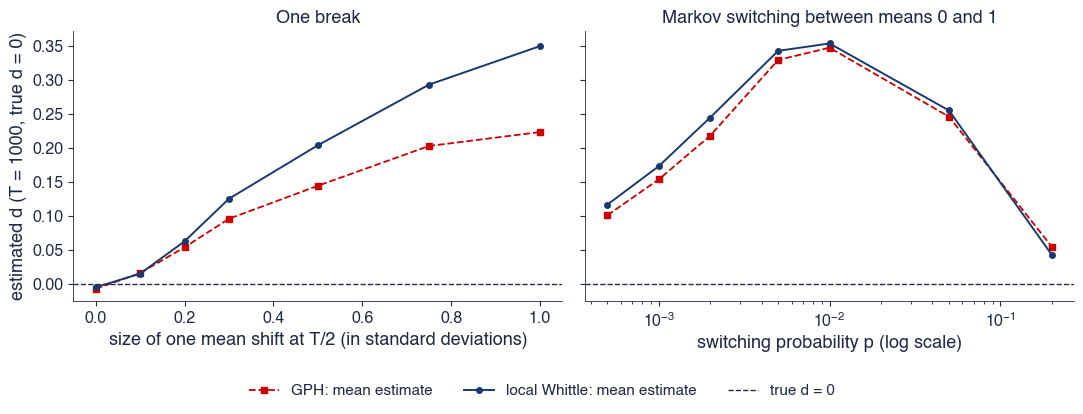

{'gph': 0.2232028573499332, 'lw': 0.349304477318095} {'gph': 0.3469451069835269, 'lw': 0.35317333860213174, 'switches': 9.81}


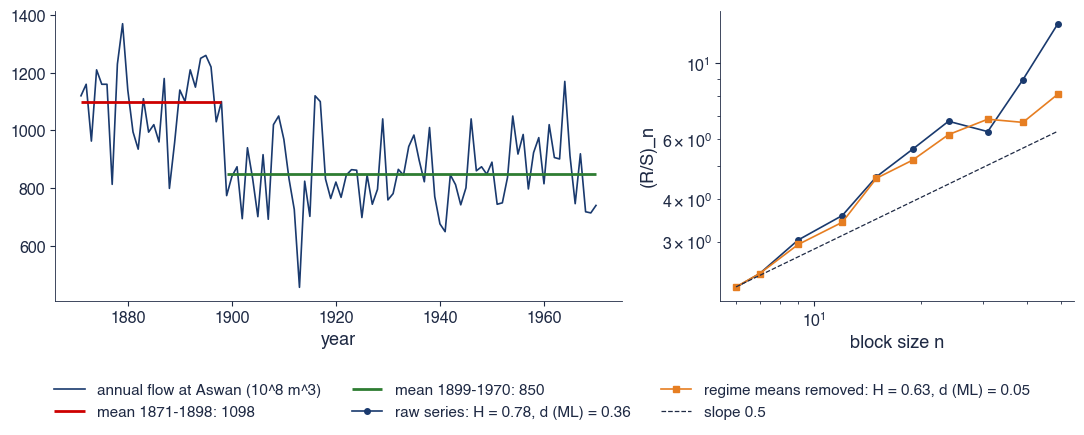

{'pre': 1097.75, 'post': 849.9722222222222, 'n_pre': 28, 'n_post': 72, 'raw': {'H': 0.7830595549503171, 'lw': 0.40297109014126853, 'lw_se': 0.11470786693528087, 'gph': 0.4354042891755117, 'gph_se': 0.1471185552560742, 'ml': 0.36420166015625005, 'ml_se': 0.06932197801962821, 'r1': 0.49840818413302884}, 'adj': {'H': 0.6331528372301882, 'lw': -0.16810171992326045, 'lw_se': 0.11470786693528087, 'gph': -0.06657898033405273, 'gph_se': 0.1471185552560742, 'ml': 0.04667236328124874, 'ml_se': 0.10162482458726678, 'r1': 0.15985615215706303}, 'drop': 22.571421341633148}


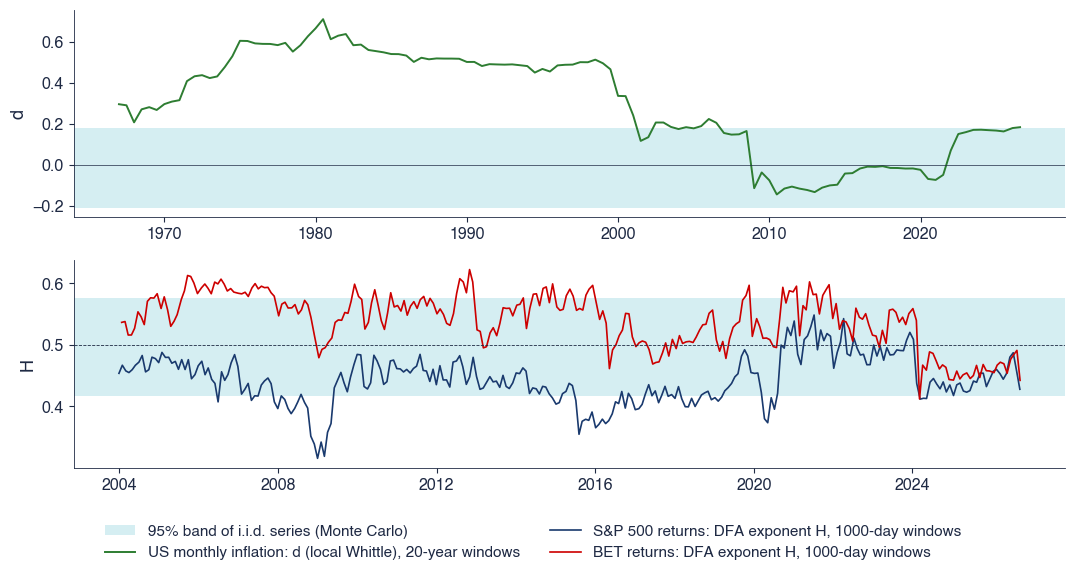

{'max': 0.7092671551858384, 'max_d': '1980-07-01', 'min': -0.14308618993036137, 'min_d': '2010-07-01', 'last': 0.18398823425634414, 'band': {'q025': -0.20876960322028235, 'q975': 0.18231319927167286, 'mean': -0.002945675384693127}, 'first_end': '1967-01-01'}


In [14]:
def fig_spurious(T=1000, reps=200, save_it=True):
    """Short-memory series that look like long memory: (a) i.i.d. N(0,1) with one mean shift of delta at T/2;
    (b) a two-state Markov-switching mean (0 or 1) with switching probability p, plus N(0,1) noise
    (Diebold and Inoue 2001). Mean GPH and local Whittle estimates of d."""
    rng = np.random.default_rng(SEED + 21)
    br, ms = {}, {}
    for dl in SHIFTS:
        X = rng.standard_normal((reps, T))
        X[:, T // 2:] += dl
        br[str(dl)] = {'gph': float(np.mean([gph(v)['d'] for v in X])), 'lw': float(np.mean([local_whittle(v)['d'] for v in X]))}
    for p in SWITCH:
        S = np.zeros((reps, T))
        s = rng.integers(0, 2, reps)
        U = rng.random((reps, T))
        for t in range(T):
            s = np.where(U[:, t] < p, 1 - s, s)
            S[:, t] = s
        X = S + rng.standard_normal((reps, T))
        ms[str(p)] = {'gph': float(np.mean([gph(v)['d'] for v in X])), 'lw': float(np.mean([local_whittle(v)['d'] for v in X])),
                      'switches': float(np.mean(np.abs(np.diff(S, axis=1)).sum(axis=1)))}
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
    axes[0].plot(SHIFTS, [br[str(d)]['gph'] for d in SHIFTS], 's--', color=st.IDAred, lw=1.3, ms=4, label='GPH: mean estimate')
    axes[0].plot(SHIFTS, [br[str(d)]['lw'] for d in SHIFTS], 'o-', color=st.MainBlue, lw=1.4, ms=4, label='local Whittle: mean estimate')
    axes[0].set_xlabel('size of one mean shift at T/2 (in standard deviations)')
    axes[0].set_ylabel(f'estimated d (T = {T}, true d = 0)')
    axes[0].set_title('One break')
    axes[1].semilogx(SWITCH, [ms[str(p)]['gph'] for p in SWITCH], 's--', color=st.IDAred, lw=1.3, ms=4, label='_')
    axes[1].semilogx(SWITCH, [ms[str(p)]['lw'] for p in SWITCH], 'o-', color=st.MainBlue, lw=1.4, ms=4, label='_')
    axes[1].set_xlabel('switching probability p (log scale)')
    axes[1].set_title('Markov switching between means 0 and 1')
    for ax in axes:
        ax.axhline(0, color=st.DarkText, ls='--', lw=1.0, label='true d = 0' if ax is axes[0] else '_')
    st.fig_legend_bottom(fig, ncol=3, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_spurious', save_it)
    return {'T': T, 'reps': reps, 'break': br, 'switch': ms}


def fig_nile_break(save_it=True):
    """The Nile flow with the two regime means; R/S, local Whittle, GPH and exact ML before and after removing the
    regime means."""
    y = nile()
    pre, post = y.loc[:NILE_BREAK], y.loc[NILE_BREAK + 1:]
    adj = pd.concat([pre - pre.mean(), post - post.mean()])
    sizes = block_sizes(len(y), nmin=6, nmax=len(y) // 2, num=10)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), gridspec_kw={'width_ratios': [1.6, 1]})
    axes[0].plot(y.index, y.values, color=COLORS['nile'], lw=1.2, label='annual flow at Aswan (10^8 m^3)')
    axes[0].hlines(pre.mean(), pre.index[0], pre.index[-1], color=st.IDAred, lw=2, label=f'mean 1871-{NILE_BREAK}: {pre.mean():.0f}')
    axes[0].hlines(post.mean(), post.index[0], post.index[-1], color=st.Forest, lw=2, label=f'mean {NILE_BREAK + 1}-1970: {post.mean():.0f}')
    axes[0].set_xlabel('year')
    out = {'pre': float(pre.mean()), 'post': float(post.mean()), 'n_pre': int(len(pre)), 'n_post': int(len(post))}
    for z, c, m, lab, key in [(y.values, COLORS['nile'], 'o-', 'raw series', 'raw'), (adj.values, st.Orange, 's-', 'regime means removed', 'adj')]:
        n, rs = rs_curve(z, sizes)
        H = float(np.polyfit(np.log10(n), np.log10(rs), 1)[0])
        lw, g = local_whittle(z), gph(z)
        ml = arfima_exact_ml(z)
        axes[1].loglog(n, rs, m, color=c, lw=1.2, ms=4, label=f"{lab}: H = {H:.2f}, d (ML) = {ml['d']:.2f}")
        out[key] = {'H': H, 'lw': lw['d'], 'lw_se': lw['se'], 'gph': g['d'], 'gph_se': g['se'], 'ml': ml['d'], 'ml_se': ml['se_d'],
                    'r1': float(acf(z, 1)[0])}
    axes[1].loglog(n, (n / n[0]) ** 0.5 * rs[0], color=st.DarkText, ls='--', lw=0.9, label='slope 0.5')
    axes[1].set_xlabel('block size n')
    axes[1].set_ylabel('(R/S)_n')
    st.fig_legend_bottom(fig, ncol=3, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_nile_break', save_it)
    out['drop'] = float(100 * (1 - post.mean() / pre.mean()))
    return out


def fig_rolling(save_it=True):
    """Top: local Whittle d of US monthly inflation in rolling 20-year windows; bottom: DFA exponents of daily
    S&P 500 and BET returns in rolling 1000-day windows; shaded: 95% Monte Carlo bands of i.i.d. series."""
    W = 240
    u = us_inflation()
    du = rolling_d(u, W, 6)
    bu = mc_band(W, lambda v: local_whittle(v)['d'])
    bh = mc_band(WINDOW, lambda v: hurst_dfa(v, block_sizes(WINDOW)))
    fig, axes = plt.subplots(2, 1, figsize=(11, 5.4))
    axes[0].axhspan(bu['q025'], bu['q975'], color=st.Teal, alpha=0.18, lw=0, label='95% band of i.i.d. series (Monte Carlo)')
    axes[0].plot(du.index, du.values, color=COLORS['usinfl'], lw=1.4, label='US monthly inflation: d (local Whittle), 20-year windows')
    axes[0].axhline(0, color=st.DarkText, lw=0.5)
    axes[0].set_ylabel('d')
    out = {'us': {'max': float(du.max()), 'max_d': du.idxmax().date().isoformat(), 'min': float(du.min()),
                  'min_d': du.idxmin().date().isoformat(), 'last': float(du.iloc[-1]), 'band': bu,
                  'first_end': du.index[0].date().isoformat()}}
    axes[1].axhspan(bh['q025'], bh['q975'], color=st.Teal, alpha=0.18, lw=0, label='_')
    for k in ('sp500', 'bet'):
        h = rolling_hurst(returns(k))
        axes[1].plot(h.index, h.values, color=COLORS[k], lw=1.2, label=f'{NAME[k]} returns: DFA exponent H, 1000-day windows')
        out[k] = {'min': float(h.min()), 'max': float(h.max()), 'max_d': h.idxmax().date().isoformat(),
                  'min_d': h.idxmin().date().isoformat(), 'last': float(h.iloc[-1]), 'above': float(np.mean(h > bh['q975'])),
                  'first': float(h.iloc[0]), 'first_d': h.index[0].date().isoformat(), 'n': int(len(h))}
    axes[1].axhline(0.5, color=st.DarkText, lw=0.6, ls='--')
    axes[1].set_ylabel('H')
    out['band_h'] = bh
    st.fig_legend_bottom(fig, ncol=2, y=0.03)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    save('tsa_ch8_rolling', save_it)
    return out


sp = fig_spurious(reps=100, save_it=False)
print(sp['break']['1.0'], sp['switch']['0.01'])
print(fig_nile_break(save_it=False))
ro = fig_rolling(save_it=False)
print(ro['us'])

## Exercises

1. Estimate $d$ of Romanian monthly inflation on 2005–2019 only: does the 2021–2023 surge change it?
2. Fit FIGARCH(1,d,1) to EUR/RON returns (`returns('eurron')`) and compare its BIC with GARCH(1,1).
3. Simulate ARFIMA(1,0.3,0) with $\phi = 0.5$ (`sim_arfima(1000, 0.3, rng, phi=[0.5])`) and compare GPH, local Whittle and exact ML of ARFIMA(1,d,0).